# PPMI Dataset Pre-processing

### Participant_Status_14Dec2025.csv

In [116]:
# Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Allow pandas to show all columns
pd.set_option('display.max_columns', None)

In [2]:
# Load the dataframe
df = pd.read_csv("../../ppmi_pd/Participant_Status_14Dec2025.csv")

# Display info and head to understand columns
print(df.info())
print(df.head())

# Also print all column names to help with categorization
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7905 entries, 0 to 7904
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PATNO               7905 non-null   int64  
 1   COHORT              7905 non-null   int64  
 2   COHORT_DEFINITION   7905 non-null   object 
 3   ENROLL_DATE         4509 non-null   object 
 4   ENROLL_STATUS       7905 non-null   object 
 5   STATUS_DATE         7904 non-null   object 
 6   SCREENEDAM          5816 non-null   float64
 7   ENROLL_AGE          4498 non-null   float64
 8   INEXPAGE            5820 non-null   object 
 9   AV133STDY           7058 non-null   float64
 10  TAUSTDY             7052 non-null   float64
 11  GAITSTDY            7052 non-null   float64
 12  PISTDY              7052 non-null   float64
 13  SV2ASTDY            7052 non-null   float64
 14  NXTAUSTDY           7052 non-null   float64
 15  DPPDSTDY            7052 non-null   float64
 16  DPPROS

In [3]:
# Load data dictionary and create column annotations
dd_df = pd.read_csv("../../ppmi_pd/Data___Databases/Data_Dictionary_-__Annotated__14Dec2025.csv")

# Filter for PATIENT_STATUS module first (primary source)
patient_status_dd = dd_df[dd_df['MOD_NAME'] == 'PATIENT_STATUS'].copy()

# Create a dictionary mapping column names (ITM_NAME) to descriptions (DSCR)
# Handle cases where ITM_NAME might be empty or spaces
column_annotations = {}
for idx, row in patient_status_dd.iterrows():
    itm_name = str(row['ITM_NAME']).strip()
    dscr = str(row['DSCR']).strip()
    
    # Skip empty ITM_NAME (these are module header rows)
    if itm_name and itm_name != 'nan' and itm_name != '':
        column_annotations[itm_name] = dscr if dscr != 'nan' else ''

# For any columns in df that are not found in PATIENT_STATUS, search across all modules
for col in df.columns:
    if col not in column_annotations:
        # Search for this column name across all modules
        col_rows = dd_df[dd_df['ITM_NAME'] == col]
        if not col_rows.empty:
            # Take the first match (or could prefer PATIENT_STATUS if multiple exist)
            dscr = str(col_rows.iloc[0]['DSCR']).strip()
            column_annotations[col] = dscr if dscr != 'nan' else ''

# Print column annotations for verification
print("Column Annotations Found:")
print("-" * 80)
for col in df.columns:
    if col in column_annotations and column_annotations[col]:
        print(f"{col:25s}: {column_annotations[col]}")
    else:
        print(f"{col:25s}: [Description not found in data dictionary]")
print("-" * 80)

# Store column annotations as a dictionary attribute for later use
df.attrs['column_descriptions'] = column_annotations


Column Annotations Found:
--------------------------------------------------------------------------------
PATNO                    : Participant ID
COHORT                   : Enrollment Cohort
COHORT_DEFINITION        : Decoded Value for COHORT
ENROLL_DATE              : Enrollment Date
ENROLL_STATUS            : Enrollment Status
STATUS_DATE              : Date Enrollment Status Occurred
SCREENEDAM               : PPMI Clinical Amendment Participant was Screened under
ENROLL_AGE               : Age at Enrollment
INEXPAGE                 : PPMI Clinical Inclusion/Criteria
AV133STDY                : Participant in PPMI Clinical Early Imaging Sub-Study
TAUSTDY                  : Participant in PPMI Clinical Tau Imaging Sub-Study
GAITSTDY                 : Participant in PPMI Clinical Gait Sub-Study
PISTDY                   : Participant in PPMI Clinical Prodromal Imaging Sub-Study
SV2ASTDY                 : Participant in PPMI Clinical SV2A PET Sub-Study
NXTAUSTDY                : Parti

In [4]:
print(df['COHORT_DEFINITION'].value_counts())

COHORT_DEFINITION
Prodromal              5400
Parkinson's Disease    1984
Healthy Control         440
SWEDD                    81
Name: count, dtype: int64


In [5]:
print(df['ENROLL_STATUS'].value_counts())

ENROLL_STATUS
Enrolled             3717
Screen failed        2760
Withdrew              541
Excluded              271
Screened              120
Declined              114
Complete              102
Pending                94
Withdraw Deceased      73
Baseline Withdraw      44
Screen Scheduled       38
Baseline               26
LP Eligible             4
Lost to follow-up       1
Name: count, dtype: int64


In [6]:
# Function to create the master key dataframe
def create_master_key(file_path):
    # 1. Load the raw status file
    df = pd.read_csv(file_path)

    # 2. Define the exact columns you requested
    columns_to_keep = [
        'PATNO', 
        'COHORT', 
        'COHORT_DEFINITION', 
        'ENROLL_DATE', 
        'ENROLL_STATUS',
        'STATUS_DATE',
        'ENROLL_AGE',
        'AV133STDY', 
        'TAUSTDY', 
        'GAITSTDY', 
        'PISTDY', 
        'SV2ASTDY', 
        'NXTAUSTDY', 
        'DPPDSTDY', 
        'DPPROSTDY', 
        'FD4STDY', 
        'DATELIG', 
        'PPMI_ONLINE_ENROLL', 
        'ENRLPINK1', # mutations linked to autosomal recessive early-onset PD. Rare, typically before age 40.
        'ENRLPRKN', # Parkin Mutation at Enrollment
        'ENRLSRDC', # PD without a known single genetic mutation.
        'ENRLNORM', # PD with normal sense of smell.
        'ENRLOTHGV', # Other Genetic Variant at Enrollment: Catches genetic variants not covered by the specific mutation columns
        'ENRLHPSM', # Reduced sense of smell (hyposmia) is a strong prodromal marker for PD
        'ENRLRBD', # A parasomnia where people act out dreams during REM sleep. Strong prodromal marker for PD. In PPMI
        'ENRLLRRK2', # the most common known genetic cause of PD
        'ENRLSNCA', # mutations are rare and often associated with early-onset and sometimes familial PD.
        'ENRLGBA' # mutations increase PD risk, and homozygous mutations cause Gaucher disease.
    ]

    # 3. Create the subset DataFrame
    master_df = df[columns_to_keep].copy()

    # ---------------------------------------------------------
    # FILTER 1: ENROLL_STATUS
    # ---------------------------------------------------------
    # Keeping only valid participants with longitudinal potential
    valid_statuses = [
        'Complete', 
        'Enrolled', 
        'Withdraw Deceased', 
        'Withdrew'
    ]
    master_df = master_df[master_df['ENROLL_STATUS'].isin(valid_statuses)]

    # ---------------------------------------------------------
    # FILTER 2: COHORT_DEFINITION
    # ---------------------------------------------------------
    # Mapping "PD" to the CSV value "Parkinson's Disease"
    # This automatically excludes SWEDD and other non-relevant cohorts
    valid_cohorts = [
        'Healthy Control', 
        "Parkinson's Disease", 
        'Prodromal'
    ]
    master_df = master_df[master_df['COHORT_DEFINITION'].isin(valid_cohorts)]

    # ---------------------------------------------------------
    # FILTER 3: ENROLL_DATE
    # ---------------------------------------------------------
    # Remove rows where Enrollment Date is Missing (Null)
    master_df = master_df.dropna(subset=['ENROLL_DATE'])

    # ---------------------------------------------------------
    # CLEANUP
    # ---------------------------------------------------------
    # Convert ENROLL_DATE to actual datetime objects for math calculations
    master_df['ENROLL_DATE'] = pd.to_datetime(master_df['ENROLL_DATE'], format='%m/%Y')    
    # Reset index for a clean dataframe
    master_df.reset_index(drop=True, inplace=True)

    # ---------------------------------------------------------
    # FILTER 4: STATUS_DATE
    # ---------------------------------------------------------
    # Remove rows where Status Date is Missing (Null)
    master_df = master_df.dropna(subset=['STATUS_DATE'])

    # ---------------------------------------------------------
    # CLEANUP
    # ---------------------------------------------------------
    # Convert STATUS_DATE to actual datetime objects for math calculations
    master_df['STATUS_DATE'] = pd.to_datetime(master_df['STATUS_DATE'], format='%m/%Y')    
    # Reset index for a clean dataframe
    master_df.reset_index(drop=True, inplace=True)

    # ---------------------------------------------------------
    # FILTER 5: PPMI Clinical + PPMI Remote (remove all PPMI Online only)
    # ---------------------------------------------------------
    # Remove rows where patient register for PPMI Online only
    # Logic: Keep participants who have ENROLL_DATE (PPMI Clinical) or are in PPMI Remote
    # Remove participants who are ONLY in PPMI Online (PPMI_ONLINE_ENROLL='YES' but no Clinical enrollment)
    # Since Filter 3 already requires ENROLL_DATE, we verify that participants with PPMI_ONLINE_ENROLL='YES' 
    # also have ENROLL_DATE (meaning they're in Clinical, not Online-only)
    # Participants in PPMI Online only would have PPMI_ONLINE_ENROLL='YES' and no ENROLL_DATE,
    # but those are already removed by Filter 3. However, we add this filter to be explicit
    # and to handle edge cases where ENROLL_DATE might be null for some reason.
    
    # Remove participants who are marked as PPMI Online enrollment but have no Clinical enrollment
    # (no ENROLL_DATE means they're not in Clinical)
    master_df = master_df[~((master_df['PPMI_ONLINE_ENROLL'] == 'YES') & (master_df['ENROLL_DATE'].isna()))]
    
    # Reset index for a clean dataframe
    master_df.reset_index(drop=True, inplace=True)

    return master_df

# --- EXECUTION ---
file_path = '../../ppmi_pd/Participant_Status_14Dec2025.csv'
master_df = create_master_key(file_path)

# --- VERIFICATION ---
print(f"Final Master Key Shape: {master_df.shape}")
print("\nCohort Breakdown:")
print(master_df['COHORT_DEFINITION'].value_counts())
print("\nStatus Breakdown:")
print(master_df['ENROLL_STATUS'].value_counts())

Final Master Key Shape: (4369, 28)

Cohort Breakdown:
COHORT_DEFINITION
Prodromal              2546
Parkinson's Disease    1488
Healthy Control         335
Name: count, dtype: int64

Status Breakdown:
ENROLL_STATUS
Enrolled             3716
Withdrew              528
Withdraw Deceased      73
Complete               52
Name: count, dtype: int64


In [7]:
master_df.head(10)

,PATNO,COHORT,COHORT_DEFINITION,ENROLL_DATE,ENROLL_STATUS,STATUS_DATE,ENROLL_AGE,AV133STDY,TAUSTDY,GAITSTDY,PISTDY,SV2ASTDY,NXTAUSTDY,DPPDSTDY,DPPROSTDY,FD4STDY,DATELIG,PPMI_ONLINE_ENROLL,ENRLPINK1,ENRLPRKN,ENRLSRDC,ENRLNORM,ENRLOTHGV,ENRLHPSM,ENRLRBD,ENRLLRRK2,ENRLSNCA,ENRLGBA
0,3000,2,Healthy Control,2011-02-01,Withdrew,2024-10-01,69.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0
1,3001,1,Parkinson's Disease,2011-03-01,Enrolled,2021-09-01,65.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
2,3002,1,Parkinson's Disease,2011-03-01,Withdrew,2024-10-01,67.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
3,3003,1,Parkinson's Disease,2011-04-01,Enrolled,2022-01-01,56.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
4,3004,2,Healthy Control,2011-04-01,Enrolled,2022-01-01,59.4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0
5,3006,1,Parkinson's Disease,2011-05-01,Withdrew,2013-10-01,57.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
6,3007,1,Parkinson's Disease,2011-05-01,Withdrew,2011-06-01,64.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
7,3008,2,Healthy Control,2011-06-01,Withdrew,2024-04-01,81.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0
8,3009,2,Healthy Control,2011-06-01,Enrolled,2021-05-01,83.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0
9,3010,1,Parkinson's Disease,2011-06-01,Enrolled,2021-05-01,47.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0


## MOTOR__MDS-UPDRS

### MDS-UPDRS_Part_III_14Dec2025.csv

In [8]:
mds_updrs_part_3_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_III_14Dec2025.csv')
mds_updrs_part_3_df.head(5)

C:\Users\irovi\AppData\Local\Temp\ipykernel_12320\361327882.py:1: DtypeWarning: Columns (16,21) have mixed types. Specify dtype option on import or set low_memory=False.
  mds_updrs_part_3_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_III_14Dec2025.csv')


,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,PDTRTMNT,PDSTATE,HRPOSTMED,HRDBSON,HRDBSOFF,PDMEDYN,DBSYN,ONOFFORDER,OFFEXAM,OFFNORSN,DBSOFFYN,DBSOFFTM,ONEXAM,ONNORSN,HIFUYN,DBSONYN,DBSONTM,PDMEDDT,PDMEDTM,EXAMDT,EXAMTM,NP3SPCH,NP3FACXP,NP3RIGN,NP3RIGRU,NP3RIGLU,NP3RIGRL,NP3RIGLL,NP3FTAPR,NP3FTAPL,NP3HMOVR,NP3HMOVL,NP3PRSPR,NP3PRSPL,NP3TTAPR,NP3TTAPL,NP3LGAGR,NP3LGAGL,NP3RISNG,NP3GAIT,NP3FRZGT,NP3PSTBL,NP3POSTR,NP3BRADY,NP3PTRMR,NP3PTRML,NP3KTRMR,NP3KTRML,NP3RTARU,NP3RTALU,NP3RTARL,NP3RTALL,NP3RTALJ,NP3RTCON,NP3TOT,DYSKPRES,DYSKIRAT,NHY,ORIG_ENTRY,LAST_UPDATE
0,272451901,3000,BL,NUPDRS3,02/2011,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02/2011,13:17:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,NaN,0.0,02/2011,2020-06-25 16:02:19
1,338703101,3000,V04,NUPDRS3,03/2012,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/2012,13:47:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,0.0,03/2012,2020-06-25 16:02:22
2,385009801,3000,V06,NUPDRS3,02/2013,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02/2013,12:22:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,NaN,0.0,02/2013,2020-06-25 16:02:22
3,437131401,3000,V08,NUPDRS3,03/2014,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/2014,13:22:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,NaN,0.0,05/2014,2020-06-25 16:02:22
4,512469901,3000,V10,NUPDRS3,03/2015,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/2015,11:43:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,NaN,0.0,03/2015,2020-06-25 16:02:23


In [82]:
def create_updrs_part3_df(file_path, master_df):
    # 1. Load Data
    df = pd.read_csv(file_path)

    # 2. Filter by Master Key & Event ID
    df = df[df['PATNO'].isin(master_df['PATNO'])]
    
    # Remove Screening(SC), Symptomatic(ST), Unscheduled(U01)
    events_to_remove = ['SC', 'U01']
    df = df[~df['EVENT_ID'].isin(events_to_remove)]

    # ---------------------------------------------------------
    # STEP 3: HANDLE MEDICATION STATE
    # ---------------------------------------------------------
    def determine_med_status(row):
        if row['PDMEDYN'] == 0:
            return 'OFF'
        elif row['PDSTATE'] == 'OFF':
            return 'OFF'
        elif row['PDSTATE'] == 'ON':
            return 'ON'
        else:
            return 'Unknown' 

    df['Medication_State'] = df.apply(determine_med_status, axis=1)

    # ---------------------------------------------------------
    # STEP 4: CALCULATE SUB-SCORES & H&Y
    # ---------------------------------------------------------
    # Define Item Groups
    tremor_cols = [
        'NP3PTRMR', 'NP3PTRML', 'NP3KTRMR', 'NP3KTRML', 
        'NP3RTARU', 'NP3RTALU', 'NP3RTARL', 'NP3RTALL', 'NP3RTALJ', 'NP3RTCON'
    ]
    
    pigd_cols = [
        'NP3RISNG', 'NP3GAIT', 'NP3FRZGT', 'NP3PSTBL', 'NP3POSTR' 
    ]
    
    rigidity_cols = [
        'NP3RIGN', 'NP3RIGRU', 'NP3RIGLU', 'NP3RIGRL', 'NP3RIGLL'
    ]
    
    bradykinesia_cols = [
        'NP3FTAPR', 'NP3FTAPL', 'NP3HMOVR', 'NP3HMOVL', 
        'NP3PRSPR', 'NP3PRSPL', 'NP3TTAPR', 'NP3TTAPL', 'NP3LGAGR', 'NP3LGAGL',
        'NP3BRADY' 
    ]

    # Ensure numeric for sub-scores
    all_motor_cols = tremor_cols + pigd_cols + rigidity_cols + bradykinesia_cols
    for col in all_motor_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # [UPDATED] Ensure Hoehn & Yahr (NHY) is numeric
    # This is critical because sometimes it contains strings like "UR" (Unable to Rate)
    df['NHY'] = pd.to_numeric(df['NHY'], errors='coerce')

    # Calculate Sums
    df['Tremor_Score'] = df[tremor_cols].sum(axis=1, min_count=1)
    df['PIGD_Score'] = df[pigd_cols].sum(axis=1, min_count=1)
    df['Rigidity_Score'] = df[rigidity_cols].sum(axis=1, min_count=1)
    df['Bradykinesia_Score'] = df[bradykinesia_cols].sum(axis=1, min_count=1)

    # ---------------------------------------------------------
    # STEP 5: CLEAN UP TOTAL SCORE
    # ---------------------------------------------------------
    df['NP3TOT'] = pd.to_numeric(df['NP3TOT'], errors='coerce')
    
    # ---------------------------------------------------------
    # FINAL CLEANUP
    # ---------------------------------------------------------
    cols_to_keep = [
        'PATNO', 'EVENT_ID', 'INFODT', 
        'NP3TOT', 'Medication_State', 
        'Tremor_Score', 'PIGD_Score', 'Rigidity_Score', 'Bradykinesia_Score', 
        'NHY',              # [UPDATED] Added NHY here
        'PDMEDYN', 'DYSKPRES' 
    ]
    
    df = df[cols_to_keep].copy()
    
    # Dates 
    # Note: PPMI often uses MM/YYYY or MM/DD/YYYY. 'coerce' handles errors.
    df['INFODT'] = pd.to_datetime(df['INFODT'], errors='coerce')
    
    # Merge Enrolled Date for Timeline
    df = pd.merge(df, master_df[['PATNO', 'ENROLL_DATE']], on='PATNO', how='left')
    
    df['Months_Since_Enrollment'] = (
        (df['INFODT'] - df['ENROLL_DATE']) / pd.Timedelta(days=30.44)
    ).round().astype('Int64')

    df = df.rename(columns={'NP3TOT': 'UPDRS_III_Total'})
    df.reset_index(drop=True, inplace=True)

    return df

# --- EXECUTION ---
file_path = '../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_III_14Dec2025.csv'
# master_df must exist from previous steps
updrs_iii_df = create_updrs_part3_df(file_path, master_df)

print(f"Shape: {updrs_iii_df.shape}")
print("Medication States:\n", updrs_iii_df['Medication_State'].value_counts())
updrs_iii_df.head(10)

C:\Users\irovi\AppData\Local\Temp\ipykernel_12320\2902858974.py:5: DtypeWarning: Columns (16,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Shape: (34153, 14)
Medication States:
 Medication_State
OFF        23956
ON          8994
Unknown     1203
Name: count, dtype: int64


C:\Users\irovi\AppData\Local\Temp\ipykernel_12320\2902858974.py:87: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['INFODT'] = pd.to_datetime(df['INFODT'], errors='coerce')


,PATNO,EVENT_ID,INFODT,UPDRS_III_Total,Medication_State,Tremor_Score,PIGD_Score,Rigidity_Score,Bradykinesia_Score,NHY,PDMEDYN,DYSKPRES,ENROLL_DATE,Months_Since_Enrollment
0,3000,BL,2011-02-01,4.0,Unknown,0.0,1.0,0.0,3.0,0.0,NaN,0.0,2011-02-01,0
1,3000,V04,2012-03-01,1.0,Unknown,0.0,1.0,0.0,0.0,0.0,NaN,0.0,2011-02-01,13
2,3000,V06,2013-02-01,4.0,Unknown,0.0,1.0,0.0,3.0,0.0,NaN,0.0,2011-02-01,24
3,3000,V08,2014-03-01,2.0,Unknown,0.0,1.0,0.0,1.0,0.0,NaN,0.0,2011-02-01,37
4,3000,V10,2015-03-01,19.0,Unknown,4.0,1.0,0.0,14.0,0.0,NaN,0.0,2011-02-01,49
5,3000,V12,2016-04-01,3.0,Unknown,0.0,1.0,1.0,1.0,0.0,NaN,0.0,2011-02-01,62
6,3000,V14,2018-02-01,10.0,Unknown,2.0,1.0,1.0,6.0,0.0,NaN,0.0,2011-02-01,84
7,3000,V15,2019-03-01,5.0,OFF,0.0,1.0,0.0,4.0,0.0,0.0,0.0,2011-02-01,97
8,3000,V17,2021-05-01,3.0,OFF,0.0,1.0,0.0,2.0,0.0,0.0,0.0,2011-02-01,123
9,3001,BL,2011-03-01,12.0,OFF,2.0,1.0,2.0,5.0,1.0,0.0,0.0,2011-03-01,0


### MDS_UPDRS_Part_II__Patient_Questionnaire_14Dec2025.csv

In [34]:
mds_updrs_part_2_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/MDS_UPDRS_Part_II__Patient_Questionnaire_14Dec2025.csv')
mds_updrs_part_2_df.head(5)

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,NUPSOURC,NP2SPCH,NP2SALV,NP2SWAL,NP2EAT,NP2DRES,NP2HYGN,NP2HWRT,NP2HOBB,NP2TURN,NP2TRMR,NP2RISE,NP2WALK,NP2FREZ,NP2PTOT,ORIG_ENTRY,LAST_UPDATE
0,272451701,3000,BL,NUPDRS2P,02/2011,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,02/2011,2020-06-25 16:02:19
1,338702901,3000,V04,NUPDRS2P,03/2012,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,03/2012,2020-06-25 16:02:22
2,385009601,3000,V06,NUPDRS2P,02/2013,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,02/2013,2020-06-25 16:02:22
3,437131001,3000,V08,NUPDRS2P,03/2014,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,05/2014,2020-06-25 16:02:22
4,512467901,3000,V10,NUPDRS2P,03/2015,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,03/2015,2020-06-25 16:02:23


In [90]:
def create_updrs_part2_df(file_path, master_df_input):
    # 1. Load Data
    df = pd.read_csv(file_path)

    # 2. Filter by Master Key & Event ID
    df = df[df['PATNO'].isin(master_df_input['PATNO'])]
    
    # Remove Screening(SC), Symptomatic(ST), Unscheduled(U01)
    events_to_remove = ['SC', 'U01']
    df = df[~df['EVENT_ID'].isin(events_to_remove)]

    # ---------------------------------------------------------
    # STEP 3: HANDLE REPORTING SOURCE
    # ---------------------------------------------------------
    # Create a feature for who filled it out (1=Patient, 2/3=Caregiver involved)
    # This captures "Caregiver Burden" or "Patient Cognitive Decline" indirectly
    df['Reported_By_Caregiver'] = df['NUPSOURC'].apply(lambda x: 1 if x > 1 else 0)

    # ---------------------------------------------------------
    # STEP 4: CALCULATE SCORES
    # ---------------------------------------------------------
    # Define Item Groups
    bulbar_cols = ['NP2SPCH', 'NP2SALV', 'NP2SWAL', 'NP2EAT']
    motor_adl_cols = ['NP2DRES', 'NP2HYGN', 'NP2HWRT', 'NP2HOBB', 'NP2TURN', 'NP2TRMR', 'NP2RISE', 'NP2WALK', 'NP2FREZ']

    # Ensure numeric
    all_cols = bulbar_cols + motor_adl_cols
    for col in all_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Calculate Sub-scores
    df['UPDRS_II_Bulbar'] = df[bulbar_cols].sum(axis=1, min_count=1)
    df['UPDRS_II_MotorADL'] = df[motor_adl_cols].sum(axis=1, min_count=1)

    # Calculate Total Score (Trust provided NP2PTOT first, impute if valid)
    df['NP2PTOT'] = pd.to_numeric(df['NP2PTOT'], errors='coerce')
    
    # Create our clean Total column
    df['UPDRS_II_Total'] = df['NP2PTOT']
    
    # Optional: Impute Total if missing but items exist
    # df['UPDRS_II_Total'] = df['UPDRS_II_Total'].fillna(df[all_cols].sum(axis=1, min_count=10))

    # ---------------------------------------------------------
    # FINAL CLEANUP
    # ---------------------------------------------------------
    cols_to_keep = [
        'PATNO', 'EVENT_ID', 'INFODT', 
        'UPDRS_II_Total', 'UPDRS_II_Bulbar', 'UPDRS_II_MotorADL',
        'Reported_By_Caregiver'
    ]
    
    df = df[cols_to_keep].copy()
    
    # Dates
    df['INFODT'] = pd.to_datetime(df['INFODT'],format='%m/%Y')
    
    # Merge Enrolled Date for Timeline
    df = pd.merge(df, master_df_input[['PATNO', 'ENROLL_DATE']], on='PATNO', how='left')
    
    df['Months_Since_Enrollment'] = (
        (df['INFODT'] - df['ENROLL_DATE']) / pd.Timedelta(days=30.44)
    ).round().astype('Int64')

    df.reset_index(drop=True, inplace=True)

    return df

# --- EXECUTION ---
file_path = '../../ppmi_pd/Motor___MDS-UPDRS/MDS_UPDRS_Part_II__Patient_Questionnaire_14Dec2025.csv'
# master_df must exist
updrs_ii_df = create_updrs_part2_df(file_path, master_df)

print(f"Shape: {updrs_ii_df.shape}")
updrs_ii_df.head(10)

Shape: (31285, 9)


,PATNO,EVENT_ID,INFODT,UPDRS_II_Total,UPDRS_II_Bulbar,UPDRS_II_MotorADL,Reported_By_Caregiver,ENROLL_DATE,Months_Since_Enrollment
0,3000,BL,2011-02-01,0.0,0.0,0.0,0,2011-02-01,0
1,3000,V04,2012-03-01,0.0,0.0,0.0,0,2011-02-01,13
2,3000,V06,2013-02-01,0.0,0.0,0.0,0,2011-02-01,24
3,3000,V08,2014-03-01,0.0,0.0,0.0,0,2011-02-01,37
4,3000,V10,2015-03-01,0.0,0.0,0.0,0,2011-02-01,49
5,3000,V12,2016-04-01,0.0,0.0,0.0,0,2011-02-01,62
6,3000,V15,2019-03-01,0.0,0.0,0.0,0,2011-02-01,97
7,3000,V17,2021-05-01,0.0,0.0,0.0,0,2011-02-01,123
8,3001,BL,2011-03-01,2.0,0.0,2.0,0,2011-03-01,0
9,3001,R17,2021-11-01,11.0,2.0,9.0,0,2011-03-01,128


**Comments**

* MDS-UPDRS Part II (Motor Experiences of Daily Living) is a questionnaire where patients rate 13 activities on a scale of 0 (Normal) to 4 (Severe).

        0 = Normal
        1 = Slight
        2 = Mild
        3 = Moderate
        4 = Severe

* Reported_By_Caregiver: This is a "hidden feature" that often correlates with cognitive decline (because the patient couldn't do it themselves).

* UPDRS_II_Total: This is your main feature (or secondary target).

* Sub-scores: Splitting "Bulbar" issues from "Walking" issues helps the model distinguish between a patient who is just slow (Motor ADL) vs. one who is choking on food (Bulbar - much higher mortality risk).

In [50]:
updrs_ii_df['UPDRS_II_Total'].describe()

count    31037.000000
mean         5.416471
std          6.509277
min          0.000000
25%          0.000000
50%          3.000000
75%          8.000000
max         48.000000
Name: UPDRS_II_Total, dtype: float64

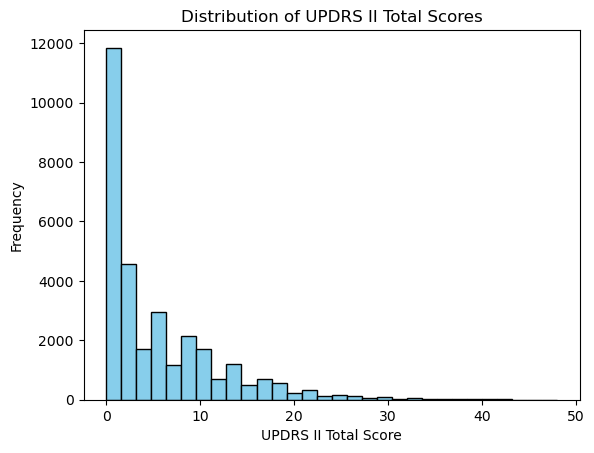

In [51]:
# Graph the distribution of UPDRS II Total Scores
import matplotlib.pyplot as plt
plt.hist(updrs_ii_df['UPDRS_II_Total'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of UPDRS II Total Scores')
plt.xlabel('UPDRS II Total Score')
plt.ylabel('Frequency')
plt.show()

### MDS-UPDRS_Part_I_14Dec2025.csv

In [84]:
def create_updrs_part1_interviewer_df(file_path, master_df):
    """
    Preprocesses MDS-UPDRS Part I: Non-Motor (Interviewer).
    Captures 'Cognitive Impairment', 'Hallucinations', and 'Apathy'.
    """
    # 1. Load Data
    df = pd.read_csv(file_path)
    
    # 2. Filter
    df = df[df['PATNO'].isin(master_df['PATNO'])]
    df = df[~df['EVENT_ID'].isin(['SC', 'ST', 'U01'])]

    # 3. Ensure Numeric Conversion
    # NP1COG: Cognitive Impairment | NP1HALL: Hallucinations | NP1DPRS: Depression
    # NP1ANXS: Anxiety | NP1APAT: Apathy | NP1DDS: Dopamine Dysregulation
    items = ['NP1COG', 'NP1HALL', 'NP1DPRS', 'NP1ANXS', 'NP1APAT', 'NP1DDS', 'NP1RTOT']
    for col in items:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 4. Feature Engineering
    # Hallucinations Flag (Major predictor of nursing home placement)
    df['Has_Hallucinations'] = df['NP1HALL'].apply(lambda x: 1 if x > 0 else 0)
    
    # Mood/Apathy Cluster
    df['Mood_Apathy_Score'] = df[['NP1DPRS', 'NP1ANXS', 'NP1APAT']].sum(axis=1, min_count=1)

    # 5. Final Cleanup
    cols_to_keep = [
        'PATNO', 'EVENT_ID', 'INFODT', 
        'NP1RTOT', 
        'NP1COG', 
        'Has_Hallucinations', 
        'Mood_Apathy_Score', 
        'NP1DDS'
    ]
    df = df[cols_to_keep].copy()
    
    # Standardize column names
    df = df.rename(columns={
        'NP1RTOT': 'UPDRS_I_Int_Total', # Explicitly label as "Interviewer Total"
        'NP1COG': 'Cognitive_Score_Part1'
    })
    
    df['INFODT'] = pd.to_datetime(df['INFODT'],format='%m/%Y')
    df.reset_index(drop=True, inplace=True)
    
    return df

# --- EXECUTION ---
file_i_int = '../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_I_14Dec2025.csv'
updrs_i_int_df = create_updrs_part1_interviewer_df(file_i_int, master_df)
print(f"Shape: {updrs_i_int_df.shape}")
updrs_i_int_df.head(10)

Shape: (28650, 8)


,PATNO,EVENT_ID,INFODT,UPDRS_I_Int_Total,Cognitive_Score_Part1,Has_Hallucinations,Mood_Apathy_Score,NP1DDS
0,3000,BL,2011-02-01,3.0,1,0,2.0,0.0
1,3000,V04,2012-03-01,1.0,0,0,1.0,0.0
2,3000,V06,2013-02-01,3.0,1,0,2.0,0.0
3,3000,V08,2014-03-01,3.0,1,0,2.0,0.0
4,3000,V10,2015-03-01,0.0,0,0,0.0,0.0
5,3000,V12,2016-04-01,3.0,1,0,2.0,0.0
6,3000,V14,2018-02-01,1.0,0,0,1.0,0.0
7,3000,V15,2019-03-01,0.0,0,0,0.0,0.0
8,3000,V17,2021-05-01,1.0,0,0,1.0,0.0
9,3001,BL,2011-03-01,0.0,0,0,0.0,0.0


### MDS-UPDRS_Part_I_Patient_Questionnaire_14Dec2025.csv

In [85]:
def create_updrs_part1_patient_df(file_path, master_df):
    """
    Preprocesses MDS-UPDRS Part I: Non-Motor (Patient Questionnaire).
    Captures 'Pain', 'Fatigue', 'Sleep', and 'Autonomic' issues.
    """
    # 1. Load Data
    df = pd.read_csv(file_path)
    
    # 2. Filter
    df = df[df['PATNO'].isin(master_df['PATNO'])]
    df = df[~df['EVENT_ID'].isin(['SC', 'ST', 'U01'])]

    # 3. Ensure Numeric Conversion
    # NP1SLPN: Night Sleep | NP1SLPD: Day Sleepiness | NP1PAIN: Pain | NP1FATG: Fatigue
    # NP1URIN: Urinary | NP1CNST: Constipation | NP1LTHD: Lightheadedness
    items = ['NP1SLPN', 'NP1SLPD', 'NP1PAIN', 'NP1URIN', 'NP1CNST', 'NP1LTHD', 'NP1FATG', 'NP1PTOT']
    for col in items:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 4. Feature Engineering
    # Sleep Issues Cluster
    df['Sleep_Score'] = df[['NP1SLPN', 'NP1SLPD']].sum(axis=1, min_count=1)
    
    # Pain & Fatigue Cluster (Major Quality of Life drivers)
    df['Pain_Fatigue_Score'] = df[['NP1PAIN', 'NP1FATG']].sum(axis=1, min_count=1)
    
    # Autonomic Cluster (Urinary + Constipation + Lightheadedness)
    df['Autonomic_Score_Part1'] = df[['NP1URIN', 'NP1CNST', 'NP1LTHD']].sum(axis=1, min_count=1)

    # 5. Final Cleanup
    cols_to_keep = [
        'PATNO', 'EVENT_ID', 'INFODT', 
        'NP1PTOT', 
        'Sleep_Score', 
        'Pain_Fatigue_Score', 
        'Autonomic_Score_Part1'
    ]
    df = df[cols_to_keep].copy()
    
    # Standardize column names
    df = df.rename(columns={
        'NP1PTOT': 'UPDRS_I_Pat_Total' # Explicitly label as "Patient Total"
    })

    df['INFODT'] = pd.to_datetime(df['INFODT'],format='%m/%Y')
    df.reset_index(drop=True, inplace=True)
    
    return df

# --- EXECUTION ---
file_i_pat = '../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_I_Patient_Questionnaire_14Dec2025.csv'
updrs_i_pat_df = create_updrs_part1_patient_df(file_i_pat, master_df)
print(f"Shape: {updrs_i_pat_df.shape}")
updrs_i_pat_df.head(10)

Shape: (31079, 7)


,PATNO,EVENT_ID,INFODT,UPDRS_I_Pat_Total,Sleep_Score,Pain_Fatigue_Score,Autonomic_Score_Part1
0,3000,BL,2011-02-01,3.0,3.0,0.0,0.0
1,3000,V04,2012-03-01,4.0,2.0,1.0,1.0
2,3000,V06,2013-02-01,3.0,3.0,0.0,0.0
3,3000,V08,2014-03-01,6.0,5.0,0.0,1.0
4,3000,V10,2015-03-01,6.0,2.0,2.0,2.0
5,3000,V12,2016-04-01,8.0,3.0,1.0,4.0
6,3000,V15,2019-03-01,2.0,1.0,0.0,1.0
7,3000,V17,2021-05-01,4.0,1.0,0.0,3.0
8,3001,BL,2011-03-01,8.0,3.0,1.0,4.0
9,3001,R17,2021-11-01,11.0,3.0,3.0,5.0


### MDS-UPDRS_Part_IV__Motor_Complications_14Dec2025.csv

In [95]:
def create_updrs_part4_df(file_path, master_df):
    """
    Preprocesses MDS-UPDRS Part IV: Motor Complications.
    Captures 'Fluctuations' (OFF time) and 'Dyskinesia' (Jerky movements).
    """
    # 1. Load Data
    df = pd.read_csv(file_path)
    
    # 2. Filter by Master Key & Standard Events
    df = df[df['PATNO'].isin(master_df['PATNO'])]
    # Remove Screening (SC), Symptomatic Therapy (ST), Unscheduled (U01)
    df = df[~df['EVENT_ID'].isin(['SC', 'U01'])]

    # 3. Ensure Numeric Conversion
    # NP4WDYSK: Time spent with dyskinesia
    # NP4DYSKI: Functional impact of dyskinesia
    # NP4OFF:   Time spent in OFF state
    # NP4FLCTI: Functional impact of fluctuations
    cols_to_numeric = ['NP4WDYSK', 'NP4DYSKI', 'NP4OFF', 'NP4FLCTI', 'NP4DYSTN', 'NP4TOT']
    for col in cols_to_numeric:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 4. Feature Engineering
    # Binary Flags: Does the patient have these complications? (Any score > 0 means "Yes")
    df['Has_Dyskinesia'] = df['NP4WDYSK'].apply(lambda x: 1 if x > 0 else 0)
    df['Has_Fluctuations'] = df['NP4OFF'].apply(lambda x: 1 if x > 0 else 0)
    
    # Severity Sub-scores
    df['Dyskinesia_Score'] = df[['NP4WDYSK', 'NP4DYSKI']].sum(axis=1, min_count=1)
    df['Fluctuation_Score'] = df[['NP4OFF', 'NP4FLCTI']].sum(axis=1, min_count=1)

    # 5. Final Cleanup
    cols_to_keep = [
        'PATNO', 'EVENT_ID', 'INFODT', 
        'NP4TOT', 
        'Dyskinesia_Score', 'Fluctuation_Score', 
        'Has_Dyskinesia', 'Has_Fluctuations'
    ]
    df = df[cols_to_keep].copy()
    
    # Standardize column names
    df = df.rename(columns={
        'NP4TOT': 'UPDRS_IV_Total'
    })

    df['INFODT'] = pd.to_datetime(df['INFODT'], format='%m/%Y')
    df.reset_index(drop=True, inplace=True)
    
    return df

# --- EXECUTION ---
file_iv = '../../ppmi_pd/Motor___MDS-UPDRS/MDS-UPDRS_Part_IV__Motor_Complications_14Dec2025.csv'
updrs_iv_df = create_updrs_part4_df(file_iv, master_df)
print(f"Shape: {updrs_iv_df.shape}")
updrs_iv_df.head(10)

Shape: (10248, 8)


,PATNO,EVENT_ID,INFODT,UPDRS_IV_Total,Dyskinesia_Score,Fluctuation_Score,Has_Dyskinesia,Has_Fluctuations
0,3001,R17,2021-11-01,1.0,1,0.0,1,0
1,3001,R18,2022-09-01,3.0,3,0.0,1,0
2,3001,V09,2014-11-01,0.0,0,0.0,0,0
3,3001,V10,2015-04-01,0.0,0,0.0,0,0
4,3001,V12,2016-06-01,0.0,0,0.0,0,0
5,3001,V14,2018-03-01,1.0,1,0.0,1,0
6,3001,V15,2019-03-01,1.0,1,0.0,1,0
7,3001,V17,2021-09-01,1.0,1,0.0,1,0
8,3001,V18,2022-07-01,1.0,1,0.0,1,0
9,3001,V19,2023-03-01,11.0,3,4.0,1,1


### Consolidated Motor__MDS-UPDRS Files

In [115]:
def create_total_updrs_df(master_df, updrs_i_int_df, updrs_i_pat_df, updrs_ii_df, updrs_iii_df, updrs_iv_df):
    """
    Merges all UPDRS parts.
    CRITICAL: Fills Part IV NaNs with 0 for valid visits, 
    because 'Missing Part IV' usually means 'Patient not on meds yet' (Score=0).
    """
    
    # 1. Start with Part III (The Motor Exam Anchor)
    merged = updrs_iii_df[['PATNO', 'EVENT_ID', 'INFODT', 'UPDRS_III_Total', 'NHY', 'Medication_State']].copy()
    
    # 2. Merge Parts I and II (The Daily Living & Non-Motor)
    # These are done for EVERYONE, so missing values here are genuine missing data.
    merged = pd.merge(merged, updrs_ii_df[['PATNO', 'EVENT_ID', 'UPDRS_II_Total']], on=['PATNO', 'EVENT_ID'], how='left')
    merged = pd.merge(merged, updrs_i_int_df[['PATNO', 'EVENT_ID', 'UPDRS_I_Int_Total']], on=['PATNO', 'EVENT_ID'], how='left')
    merged = pd.merge(merged, updrs_i_pat_df[['PATNO', 'EVENT_ID', 'UPDRS_I_Pat_Total']], on=['PATNO', 'EVENT_ID'], how='left')
    
    # 3. Merge Part IV (The Complications)
    # This is ONLY done for medicated patients.
    merged = pd.merge(merged, updrs_iv_df[['PATNO', 'EVENT_ID', 'UPDRS_IV_Total']], on=['PATNO', 'EVENT_ID'], how='left')
    
    # 4. Rename Columns for Clarity
    merged = merged.rename(columns={
        'UPDRS_I_Int_Total': 'Part_I_Int',
        'UPDRS_I_Pat_Total': 'Part_I_Pat',
        'UPDRS_II_Total': 'Part_II',
        'UPDRS_III_Total': 'Part_III',
        'UPDRS_IV_Total': 'Part_IV'
    })

    # ---------------------------------------------------------
    # CRITICAL FIX: FILL PART IV NA with 0
    # ---------------------------------------------------------
    # Logic: If Part III exists (valid visit), but Part IV is missing, 
    # it implies the patient is not on meds. 
    # Therefore, Dyskinesia/Fluctuations = 0.
    
    # Only fill NaN if the row is otherwise valid (i.e., has Part III)
    # We do this in-place for the column 'Part_IV'
    merged['Part_IV'] = merged['Part_IV'].fillna(0)

    # ---------------------------------------------------------
    # CALCULATE TOTAL SCORE
    # ---------------------------------------------------------
    parts = ['Part_I_Int', 'Part_I_Pat', 'Part_II', 'Part_III', 'Part_IV']
    
    # Sum across columns. 
    # min_count=3 prevents summing rows that are almost entirely empty.
    merged['MDS_UPDRS_Total'] = merged[parts].sum(axis=1, min_count=3)

    # 5. Filter by Master List
    merged = merged[merged['PATNO'].isin(master_df['PATNO'])]
    
    # Sort for review
    merged = merged.sort_values(['PATNO', 'INFODT'])

    return merged


# --- EXECUTION ---
# Assuming you have all these dfs ready from previous steps:
total_motor_df = create_total_updrs_df(
    master_df, 
    updrs_i_int_df, 
    updrs_i_pat_df, 
    updrs_ii_df, 
    updrs_iii_df, 
    updrs_iv_df
)
total_motor_df.head()

,PATNO,EVENT_ID,INFODT,Part_III,NHY,Medication_State,Part_II,Part_I_Int,Part_I_Pat,Part_IV,MDS_UPDRS_Total
0,3000,BL,2011-02-01,4.0,0.0,Unknown,0.0,3.0,3.0,0.0,10.0
1,3000,V04,2012-03-01,1.0,0.0,Unknown,0.0,1.0,4.0,0.0,6.0
2,3000,V06,2013-02-01,4.0,0.0,Unknown,0.0,3.0,3.0,0.0,10.0
3,3000,V08,2014-03-01,2.0,0.0,Unknown,0.0,3.0,6.0,0.0,11.0
4,3000,V10,2015-03-01,19.0,0.0,Unknown,0.0,0.0,6.0,0.0,25.0


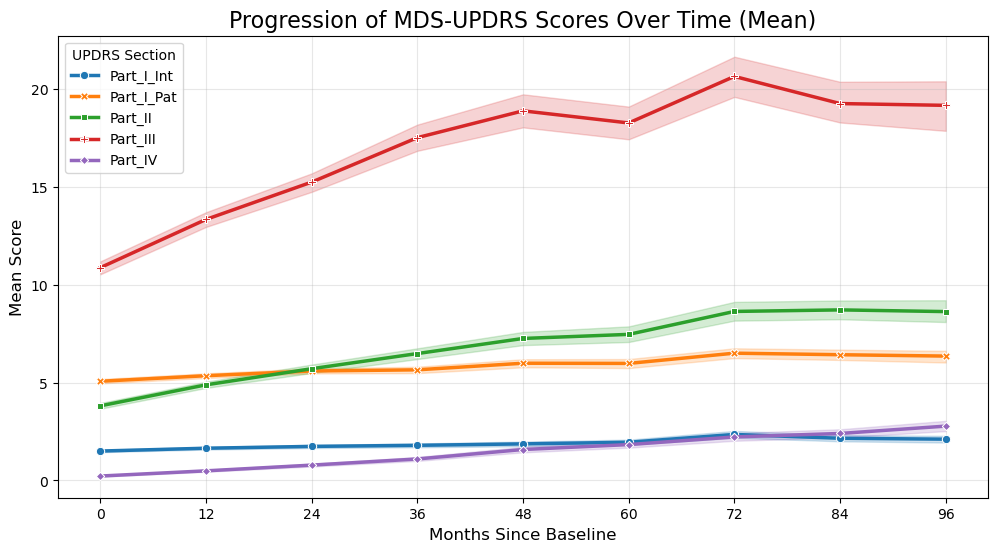

In [117]:
def plot_updrs_progression(df):
    # Filter for standard visits only to make the graph clean
    # (Baseline -> Year 5)
    standard_visits = ['BL', 'V04', 'V06', 'V08', 'V10', 'V12', 'V13', 'V14', 'V15']
    plot_df = df[df['EVENT_ID'].isin(standard_visits)].copy()
    
    # Sort visits logically
    visit_order = {
        'BL': 0, 'V04': 12, 'V06': 24, 'V08': 36, 
        'V10': 48, 'V12': 60, 'V13': 72, 'V14': 84, 'V15': 96
    }
    plot_df['Month'] = plot_df['EVENT_ID'].map(visit_order)
    plot_df = plot_df.sort_values('Month')

    # Convert to Long Format for Stacked Plotting
    long_df = plot_df.melt(
        id_vars=['EVENT_ID', 'Month'], 
        value_vars=['Part_I_Int', 'Part_I_Pat', 'Part_II', 'Part_III', 'Part_IV'],
        var_name='UPDRS_Part', 
        value_name='Score'
    )

    plt.figure(figsize=(12, 6))
    
    # Plot Mean Score with Confidence Interval
    sns.lineplot(
        data=long_df, 
        x='Month', 
        y='Score', 
        hue='UPDRS_Part', 
        style='UPDRS_Part',
        markers=True, 
        dashes=False,
        linewidth=2.5
    )

    plt.title("Progression of MDS-UPDRS Scores Over Time (Mean)", fontsize=16)
    plt.xlabel("Months Since Baseline", fontsize=12)
    plt.ylabel("Mean Score", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(title='UPDRS Section')
    plt.xticks(sorted(plot_df['Month'].unique()))
    
    plt.show()

plot_updrs_progression(total_motor_df)

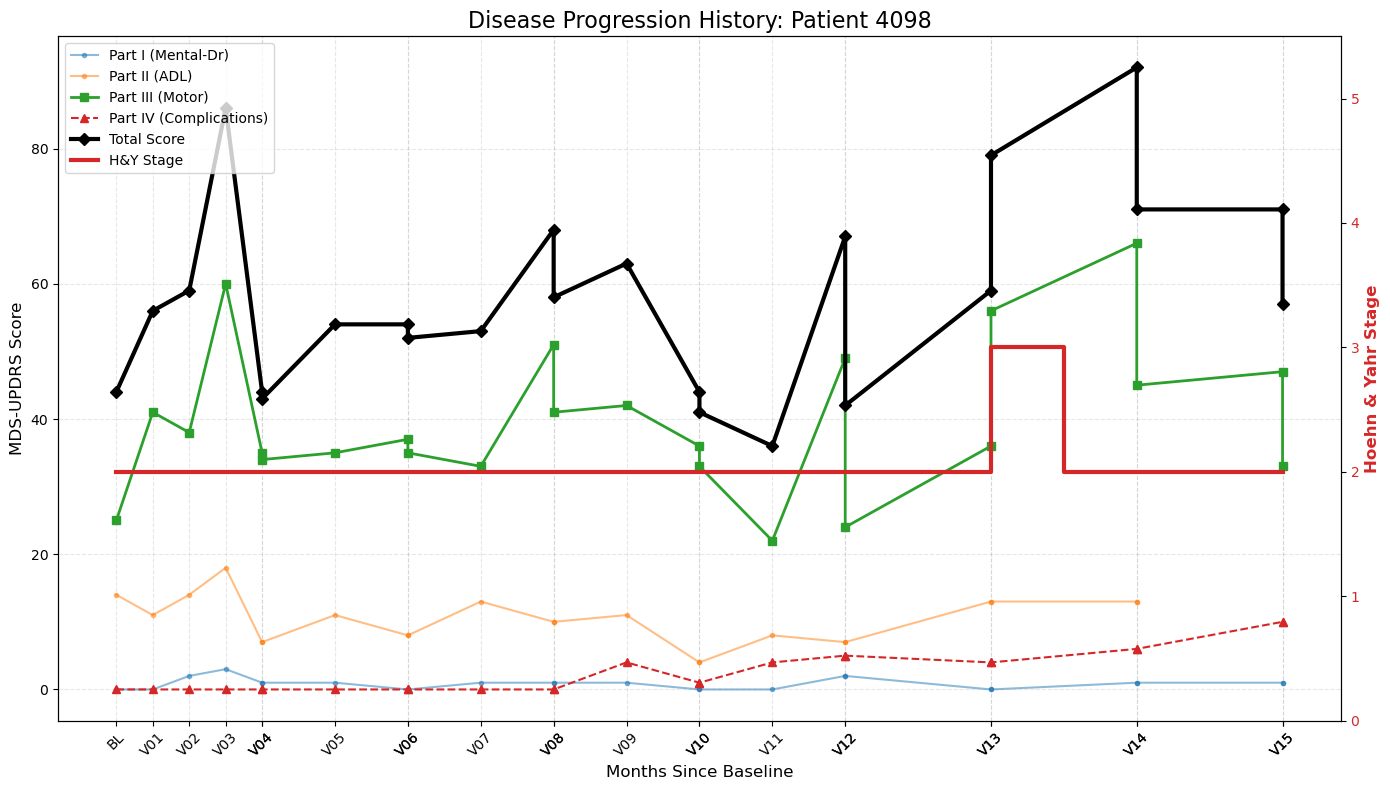

In [138]:
def plot_patient_history(df, patno):
    """
    Plots disease progression for a SINGLE patient.
    - Left Axis: UPDRS Part I, II, III, IV and Total Scores.
    - Right Axis: Hoehn & Yahr Stage (0-5).
    """
    # 1. Filter for the specific patient
    pat_df = df[df['PATNO'] == patno].copy()
    
    if pat_df.empty:
        print(f"Error: Patient {patno} not found in dataset.")
        return

    # 2. Sort & Create Timeline
    pat_df = pat_df.sort_values('INFODT')
    
    visit_order = {
        'SC': -1, 'BL': 0, 'V01': 3, 'V02': 6, 'V03': 9, 'V04': 12, 'V05': 18, 
        'V06': 24, 'V07': 30, 'V08': 36, 'V09': 42, 'V10': 48, 
        'V11': 54, 'V12': 60, 'V13': 72, 'V14': 84, 'V15': 96
    }
    pat_df['Plot_Month'] = pat_df['EVENT_ID'].map(visit_order)
    pat_df = pat_df.dropna(subset=['Plot_Month']).sort_values('Plot_Month')

    # 3. Setup Plot with Two Axes
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    # --- LEFT AXIS (UPDRS SCORES) ---
    ax1.set_xlabel('Months Since Baseline', fontsize=12)
    ax1.set_ylabel('MDS-UPDRS Score', fontsize=12, color='black')
    ax1.grid(True, linestyle='--', alpha=0.3)

    # Plot Parts (Lighter lines)
    l1, = ax1.plot(pat_df['Plot_Month'], pat_df['Part_I_Int'], marker='.', label='Part I (Mental-Dr)', alpha=0.5)
    l2, = ax1.plot(pat_df['Plot_Month'], pat_df['Part_II'], marker='.', label='Part II (ADL)', alpha=0.5)
    l3, = ax1.plot(pat_df['Plot_Month'], pat_df['Part_III'], marker='s', linewidth=2, label='Part III (Motor)')
    l4, = ax1.plot(pat_df['Plot_Month'], pat_df['Part_IV'], marker='^', linestyle='--', label='Part IV (Complications)')
    
    # Plot Total (Thick Line)
    l5, = ax1.plot(pat_df['Plot_Month'], pat_df['MDS_UPDRS_Total'], color='black', linewidth=3, marker='D', label='Total Score')

    # --- RIGHT AXIS (HOEHN & YAHR) ---
    ax2 = ax1.twinx()  # Create a second y-axis sharing the same x-axis
    ax2.set_ylabel('Hoehn & Yahr Stage', fontsize=12, color='tab:red', fontweight='bold')
    
    # Plot NHY (Stepped Line because stages are discrete steps)
    l6, = ax2.step(pat_df['Plot_Month'], pat_df['NHY'], where='mid', color='tab:red', linewidth=3, linestyle='-', label='H&Y Stage')
    
    # Set H&Y Limits (0 to 5)
    ax2.set_ylim(0, 5.5)
    ax2.set_yticks([0, 1, 2, 3, 4, 5])
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # --- LEGEND ---
    # Combine legends from both axes
    lines = [l1, l2, l3, l4, l5, l6]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True, fontsize=10)

    # --- TITLE ---
    plt.title(f"Disease Progression History: Patient {patno}", fontsize=16)
    
    # Set X-ticks to be the specific visits
    ax1.set_xticks(pat_df['Plot_Month'])
    ax1.set_xticklabels(pat_df['EVENT_ID'], rotation=45)

    plt.tight_layout()
    plt.show()

# --- EXAMPLE USAGE ---
plot_patient_history(total_motor_df, 4098)

**What to look for in this graph:**

The "Honeymoon" Phase: In the first few years (Month 0-36), you might see Part III (Motor) drop or stay stable. This is the medication working.

The "Complication" Phase: Look for when the Part IV (dotted line) starts rising from 0. This marks the onset of Dyskinesia or fluctuations.

The "Cognitive" Creep: Watch Part I (Blue lines). If these start rising steadily while Motor scores are flat, the patient is experiencing non-motor decline (dementia/apathy) which is often the bigger problem in late stage.

**Legend**

1. The X and Y Axes (The Basics)

* X-Axis (Bottom): Time in Months.

        0 = Baseline (Diagnosis).

        60 = 5 Years later.

* Left Y-Axis (Black Numbers): The MDS-UPDRS Score (0-200).

        Higher is Worse.

        0-20: Normal / Mild.

        30-50: Moderate Disability.

        >60: Severe.

* Right Y-Axis (Red Numbers): The Hoehn & Yahr Stage (0-5).

        Stage 2: Bilateral symptoms (can still walk fine).

        Stage 3: Loss of Balance (The tipping point).

2. Scenario A: The "Textbook" PD Progression (e.g., Patient 4098)

* Visual: You see a "Staircase" going up.

* Key Event 1: The Gap (Medication Effect):

        Look at the Green Line (Motor) vs. the Black Line (Total).

        In the first few years, you might see the Green line drop or stay flat while the Blue Lines (Non-Motor) keep rising.

        Meaning: The Levodopa pills are fixing the stiffness (Motor), but they cannot fix the anxiety, sleep, or memory issues (Non-Motor). The disease is still progressing "under the hood."

* Key Event 2: The Red Jump:

        Watch where the Red Step Line jumps from 2 to 3.

        Meaning: This is the moment the patient lost their balance reflexes. This often correlates with a sharp rise in the Black Line because falls lead to hospitalization and rapid decline.

3. Scenario B: The "Stable" Control (e.g., Patient 3611)

* Visual: A flat line hugging the bottom.

* Interpretation:

        The Black Line stays below 5-10 points.

        The Red Line stays at 0.

        Meaning: This confirms that "getting old" does not mean "getting Parkinson's." Any rise you see in your PD patients is disease, not age.

4. Scenario C: The "Prodromal Converter" (The Hockey Stick)

* Visual: Flat for years, then a sudden upward "Knee."

* The "Leading Edge":

        Look closely at the "Knee" (the bend).

        Does the Blue Line (Part I - Mental) start rising before the Green Line (Motor)?

        Meaning: This validates the theory that PD starts in the brain/gut (depression, constipation) years before it affects the limbs.

--- 1. COHORT MAPPING VERIFICATION ---
Using 'COHORT_DEFINITION' column for labels.
✅ FOUND PD EXAMPLE: Patient 4098 (Score Increased by 135.0 pts)
✅ FOUND CONTROL EXAMPLE: Patient 3611 (Variance: 0.00)

--- 2. GENERATING GRAPHS ---
Plotting PD Patient 4098...


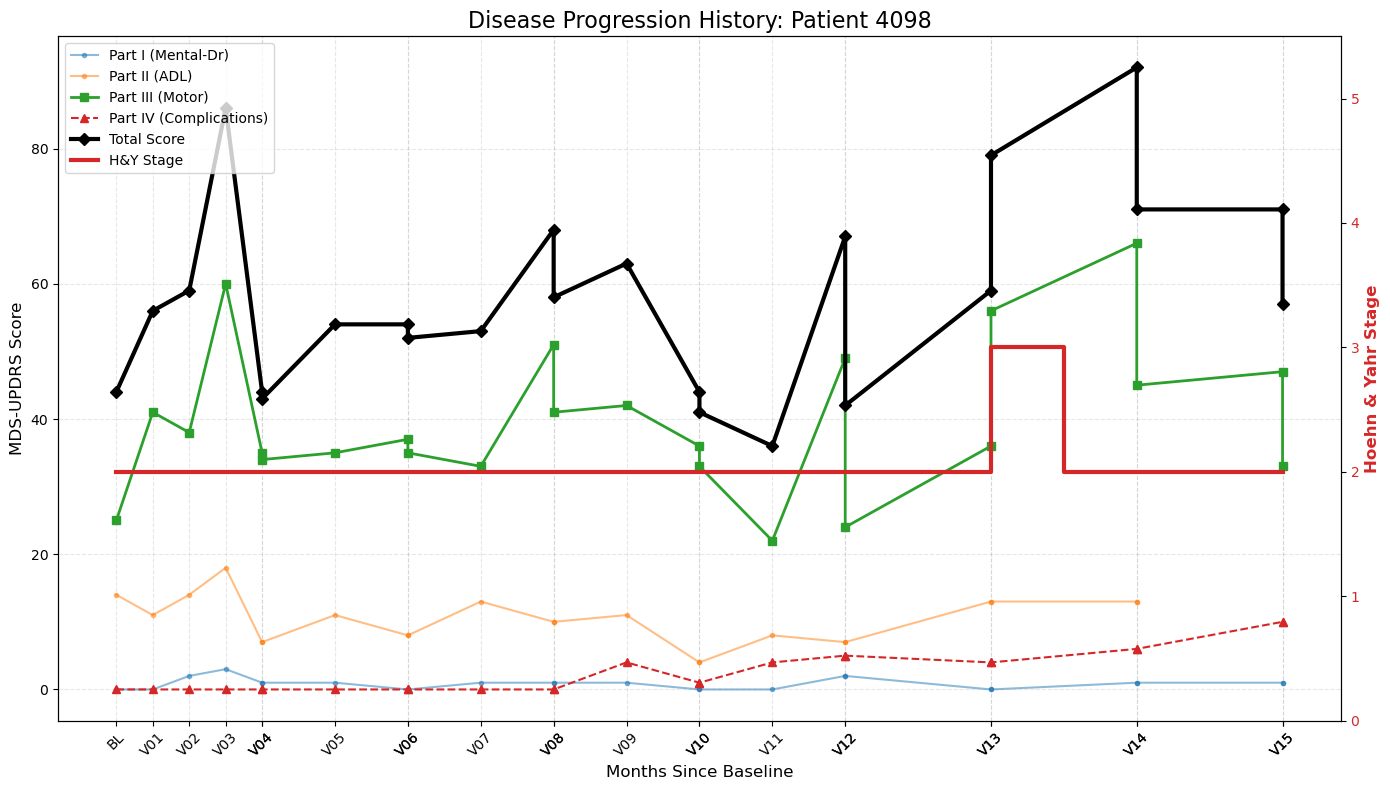

Plotting Control Patient 3611...


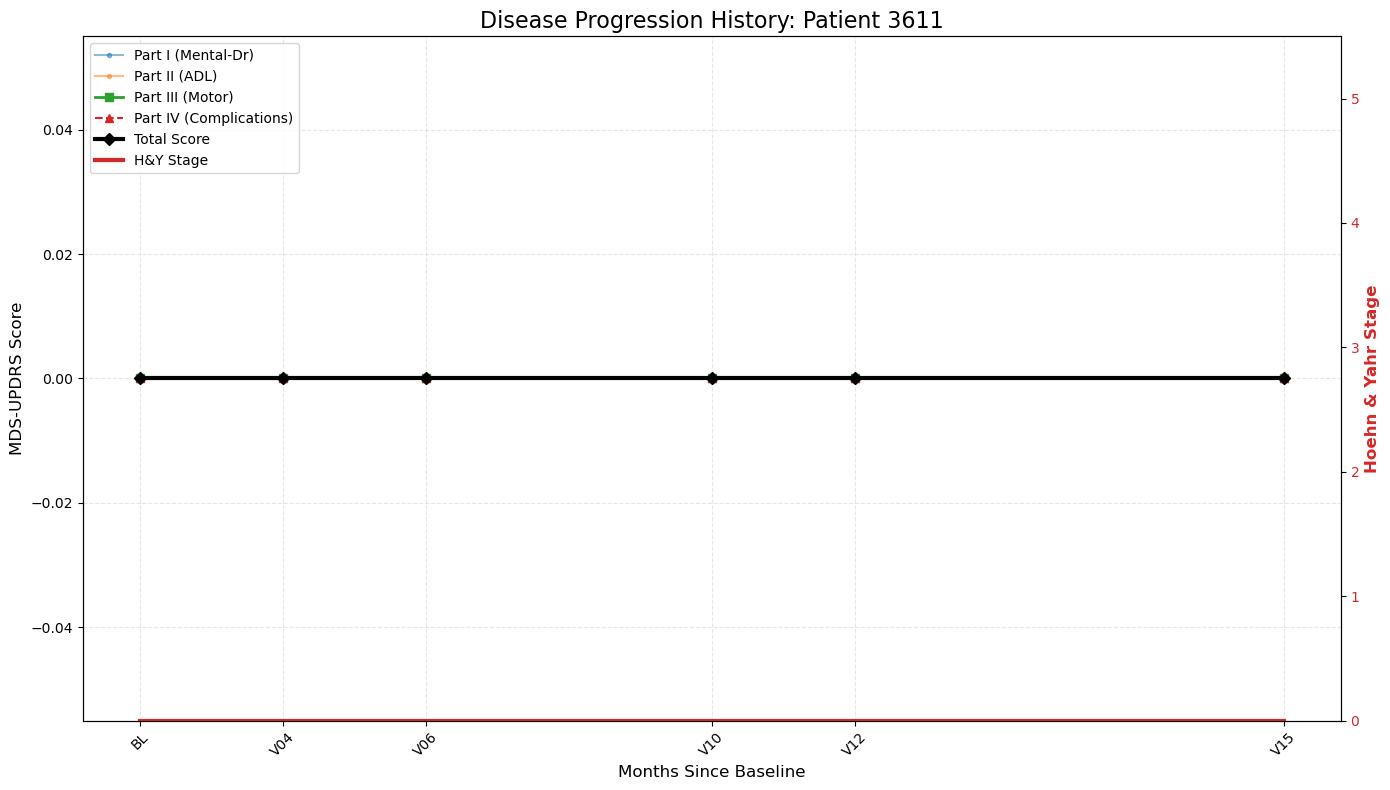

In [139]:
# Finding candidate to see PD progression 

def find_and_plot_best_patients(merged_df, master_df):
    """
    1. Maps Numeric Cohorts (1, 2) to Text (PD, Control).
    2. Finds the best 'Textbook' examples.
    3. Plots them immediately.
    """
    print("--- 1. COHORT MAPPING VERIFICATION ---")
    
    # Create a local copy to avoid modifying original frames
    df_motor = merged_df.copy()
    df_status = master_df.copy()
    
    # Ensure PATNO is int
    df_motor['PATNO'] = pd.to_numeric(df_motor['PATNO'], errors='coerce').fillna(0).astype(int)
    df_status['PATNO'] = pd.to_numeric(df_status['PATNO'], errors='coerce').fillna(0).astype(int)

    # Merge Cohort info
    # We try to get 'COHORT_DEFINITION' (Text) if it exists, otherwise use 'COHORT' (Number)
    cols_to_merge = ['PATNO', 'COHORT']
    if 'COHORT_DEFINITION' in df_status.columns:
        cols_to_merge.append('COHORT_DEFINITION')
        print("Using 'COHORT_DEFINITION' column for labels.")
    else:
        print("COHORT_DEFINITION not found. Using numeric codes.")

    # Select long-term patients (5+ visits)
    visit_counts = df_motor.groupby('PATNO')['EVENT_ID'].nunique()
    long_term_pats = visit_counts[visit_counts >= 5].index
    
    hq_df = df_motor[df_motor['PATNO'].isin(long_term_pats)]
    hq_df = pd.merge(hq_df, df_status[cols_to_merge], on='PATNO', how='left')

    # --- DEFINE TARGETS ---
    # PPMI Standard Coding: 1=PD, 2=Healthy Control
    # We look for EITHER the Number OR the String
    pd_targets = [1, "Parkinson's Disease", "PD"]
    hc_targets = [2, "Healthy Control", "Control", "HC"]
    
    best_pats = {}

    # --- FIND PD PROGRESSOR ---
    # Filter for PD
    if 'COHORT_DEFINITION' in hq_df.columns:
        pd_subset = hq_df[hq_df['COHORT_DEFINITION'].isin(pd_targets) | hq_df['COHORT'].isin(pd_targets)]
    else:
        pd_subset = hq_df[hq_df['COHORT'].isin(pd_targets)]
        
    if not pd_subset.empty:
        # Find patient with biggest Range (Max - Min score)
        ranges = pd_subset.groupby('PATNO')['MDS_UPDRS_Total'].apply(lambda x: x.max() - x.min())
        best_pats['PD_Progressor'] = ranges.idxmax()
        print(f"✅ FOUND PD EXAMPLE: Patient {best_pats['PD_Progressor']} (Score Increased by {ranges.max()} pts)")
    else:
        print("❌ Could not find any PD patients. Check Codes.")

    # --- FIND STABLE CONTROL ---
    if 'COHORT_DEFINITION' in hq_df.columns:
        hc_subset = hq_df[hq_df['COHORT_DEFINITION'].isin(hc_targets) | hq_df['COHORT'].isin(hc_targets)]
    else:
        hc_subset = hq_df[hq_df['COHORT'].isin(hc_targets)]
        
    if not hc_subset.empty:
        # Find patient with lowest Standard Deviation (Most Stable)
        variances = hc_subset.groupby('PATNO')['MDS_UPDRS_Total'].std()
        best_pats['Healthy_Control'] = variances.idxmin()
        print(f"✅ FOUND CONTROL EXAMPLE: Patient {best_pats['Healthy_Control']} (Variance: {variances.min():.2f})")
    else:
        print("❌ Could not find any Control patients. Check Codes.")

    # --- PLOTTING ---
    print("\n--- 2. GENERATING GRAPHS ---")
    
    if 'PD_Progressor' in best_pats:
        print(f"Plotting PD Patient {best_pats['PD_Progressor']}...")
        plot_patient_history(df_motor, best_pats['PD_Progressor'])
        
    if 'Healthy_Control' in best_pats:
        print(f"Plotting Control Patient {best_pats['Healthy_Control']}...")
        plot_patient_history(df_motor, best_pats['Healthy_Control'])
        
    return best_pats

# --- EXECUTION ---
# Assumes 'total_motor_df' and 'master_df' are already loaded in your environment
candidates = find_and_plot_best_patients(total_motor_df, master_df)

**Interpretation**

1. Patient 4098: The "Super-Progressor" (PD)

    "Score Increased by 135.0 points"

* The Clinical Reality: This is a catastrophic decline. A typical PD patient might worsen by 3-5 points per year. A 135-point increase means this patient went from Early Stage (likely shaking a little) to End Stage (likely bedridden or requiring full-time nursing care) within the study period.

* What to look for in the Graph:

        The "All-Systems Failure": You likely see every single line rising.

        Part III (Green): Probably skyrocketed, meaning their motor control is gone.

        Part I & II (Blue/Orange): If these are high, the patient lost their independence (Part II) and likely developed dementia/psychosis (Part I).

        H&Y (Red Line): Look at the red step-line on the right axis. It almost certainly hit Stage 4 or 5. This confirms the transition from "Walking" to "Wheelchair."

2. Patient 3611: The "Perfect Control" (Healthy)

    "Variance: 0.00"

* The Clinical Reality: This is biologically remarkable. Over 5+ years of aging, this person did not develop any significant motor or non-motor symptoms. They are the "Gold Standard" of healthy aging.

* What to look for in the Graph:

        The Flatline: The Black Line (Total Score) should be hugging the bottom of the chart (near 0).

        Noise Floor: This confirms that any "wiggle" you see in other patients that is less than ~2-3 points is just noise. If a healthy person has 0 variance, any variance in a PD patient is likely the disease signal.

--- SEARCHING FOR PHENOCONVERTER ---
Total Prodromal Candidates: 2546
✅ FOUND PRODROMAL CONVERTER: Patient 115328
   started as Prodromal, hit peak score of 109.0


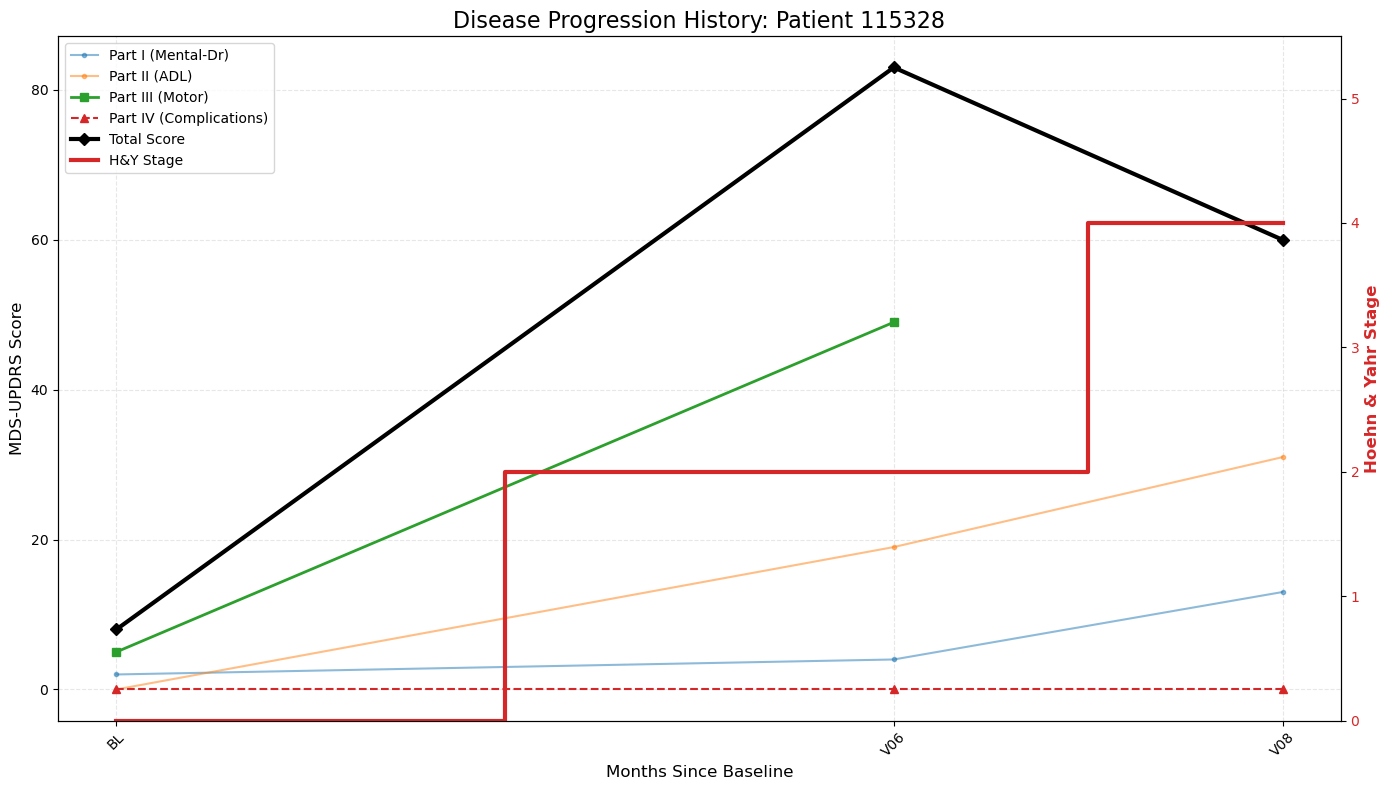

In [141]:
def find_and_plot_prodromal(merged_df, master_df):
    """
    Finds a 'Prodromal' patient who likely converted to PD.
    Criteria: Started in Prodromal Cohort, but reached a Total Score > 30.
    """
    print("--- SEARCHING FOR PHENOCONVERTER ---")
    
    # 1. Prepare Data
    df_motor = merged_df.copy()
    df_status = master_df.copy()
    
    # Ensure Int Types
    df_motor['PATNO'] = pd.to_numeric(df_motor['PATNO'], errors='coerce').fillna(0).astype(int)
    df_status['PATNO'] = pd.to_numeric(df_status['PATNO'], errors='coerce').fillna(0).astype(int)

    # 2. Filter for Prodromal Cohort
    # Prodromal codes are often 4, or text "Prodromal"
    target_cohorts = [4, "Prodromal", "Genetics Prodromal"]
    
    if 'COHORT_DEFINITION' in df_status.columns:
        prod_pats = df_status[
            df_status['COHORT'].isin(target_cohorts) | 
            df_status['COHORT_DEFINITION'].isin(target_cohorts)
        ]['PATNO'].unique()
    else:
        prod_pats = df_status[df_status['COHORT'].isin(target_cohorts)]['PATNO'].unique()
        
    print(f"Total Prodromal Candidates: {len(prod_pats)}")

    # 3. Find the "Converter" (Someone whose score got HIGH)
    # Filter motor data for these patients
    prod_motor_df = df_motor[df_motor['PATNO'].isin(prod_pats)]
    
    if prod_motor_df.empty:
        print("❌ No motor data found for Prodromal patients.")
        return

    # Get Max Score per patient
    max_scores = prod_motor_df.groupby('PATNO')['MDS_UPDRS_Total'].max()
    
    # We want someone who crossed the threshold of ~30 (Definite PD)
    # Sort by Max Score descending
    converters = max_scores[max_scores > 30].sort_values(ascending=False)
    
    if not converters.empty:
        best_candidate = converters.index[0] # The one with the highest score
        peak_score = converters.iloc[0]
        print(f"✅ FOUND PRODROMAL CONVERTER: Patient {best_candidate}")
        print(f"   started as Prodromal, hit peak score of {peak_score}")
        
        # 4. Plot
        plot_patient_history(df_motor, best_candidate)
    else:
        print("❌ No Prodromal patients found with high scores (>30).")
        # Fallback: Just plot the one with the highest variance
        fallback = prod_motor_df.groupby('PATNO')['MDS_UPDRS_Total'].std().idxmax()
        print(f"⚠️ Plotting most variable Prodromal patient instead: {fallback}")
        plot_patient_history
# --- EXECUTION ---
find_and_plot_prodromal(total_motor_df, master_df)

**Interpretation**

A peak score of 109.0 is extremely high. For context:

        0-10: Healthy / Prodromal

        30: Diagnosis of Parkinson's

        109: Severe Disability (likely wheelchair-bound, severe dementia, or inability to care for self).

Here is the "Medical Detective" breakdown of what this graph tells us about Patient 115328:

1. The "Silent" Phase (The Start)

At the beginning (left side of the graph), this patient was labeled Prodromal.

        What you see: The lines were likely low (< 10 points).

        The Reality: Even though they looked "fine," their brain was already accumulating alpha-synuclein damage. They likely had RBD (Acting out dreams) or Hyposmia (Smell loss). This was the "ticking clock" phase.

2. The "Explosion" (The Slope)

To get from Prodromal (Score ~5) to Severe (Score 109) within the study timeframe implies a Very Rapid Decline.

        The Interpretation: This is not "Typical" Parkinson's (which moves slowly). This is likely the "Diffuse Malignant" phenotype.

        Key Insight for ML: Your model needs to identify this patient before the explosion. If you look at their "Part I (Non-Motor)" score in the early years, it was likely creeping up (Anxiety, Cognitive slowing) before the motor explosion happened.

3. The "Crossover" (The Diagnosis)

Look at the point where the Green Line (Motor) suddenly shoots vertical.

        That exact month is the Date of Conversion.

        Before that date, they were "At Risk." After that date, they were "Patients."

### Modified_Schwab___England_Activities_of_Daily_Living_14Dec2025.csv

In [60]:
def create_schwab_df(file_path):
    # 1. Load the raw Schwab & England file
    schwab_df = pd.read_csv(file_path)

    # 2. Define the exact columns needed
    columns_to_keep = [
        'REC_ID',
        'PATNO',
        'EVENT_ID',
        'INFODT',
        'MSEADLG',
        'LAST_UPDATE'
    ]
    
    # 3. Create the subset DataFrame
    schwab_df = schwab_df[columns_to_keep].copy()

    # Filter using your Master Key
    schwab_df = schwab_df[schwab_df['PATNO'].isin(master_df['PATNO'])]

    # 4. Filter out EVENT_IDs that are not relevant
    # REMOVE 'SC', 'ST', 'U01'
    events_to_remove = ['SC', 'U01']
    
    # Keep rows where EVENT_ID is NOT in the remove list
    schwab_df = schwab_df[~schwab_df['EVENT_ID'].isin(events_to_remove)]

    # ---------------------------------------------------------
    # CLEANUP
    # ---------------------------------------------------------
    # Remove rows where MSEADLG is Missing (Null)
    schwab_df = schwab_df.dropna(subset=['MSEADLG'])
    print('Check for missing value:\n', schwab_df.isnull().sum())

    # Reset index for a clean dataframe
    schwab_df.reset_index(drop=True, inplace=True)


    # Convert INFODT to datetime
    schwab_df['INFODT'] = pd.to_datetime(schwab_df['INFODT'],format='%m/%Y')

    # Merge with Master Key to get the Anchor Date (ENROLL_DATE)
    schwab_df = pd.merge(schwab_df, master_df[['PATNO', 'ENROLL_DATE']], on='PATNO', how='left')

    return schwab_df

# --- EXECUTION ---
file_path = '../../ppmi_pd/Motor___MDS-UPDRS/Modified_Schwab___England_Activities_of_Daily_Living_14Dec2025.csv'
schwab_df = create_schwab_df(file_path)

# Calculate Timeline
schwab_df['Months_Since_Enrollment'] = (
    (schwab_df['INFODT'] - schwab_df['ENROLL_DATE']) / pd.Timedelta(days=30.44)
).round().astype('Int64')

# Rename for consistency
schwab_df = schwab_df.rename(columns={'INFODT': 'VISIT_DATE', 'MSEADLG': 'Schwab_England_Score'})
print(schwab_df.shape)
schwab_df.head(10)

Check for missing value:
 REC_ID         0
PATNO          0
EVENT_ID       0
INFODT         0
MSEADLG        0
LAST_UPDATE    0
dtype: int64
(27418, 8)


,REC_ID,PATNO,EVENT_ID,VISIT_DATE,Schwab_England_Score,LAST_UPDATE,ENROLL_DATE,Months_Since_Enrollment
0,IA123379,3000,V17,2021-05-01,95.0,2021-06-01 00:00:00,2011-02-01,123
1,278744301,3001,BL,2011-03-01,95.0,2020-06-25 16:04:30,2011-03-01,0
2,IA123380,3001,R17,2021-11-01,65.0,2021-12-02 00:00:00,2011-03-01,128
3,IA123383,3001,R18,2022-09-01,70.0,2022-09-30 00:00:00,2011-03-01,138
4,IA318975,3001,R19,2023-08-01,70.0,2023-08-23 00:00:00,2011-03-01,149
5,294965201,3001,V01,2011-05-01,95.0,2020-06-25 16:04:33,2011-03-01,2
6,310817701,3001,V02,2011-08-01,95.0,2020-06-25 16:04:33,2011-03-01,5
7,322771101,3001,V03,2011-11-01,90.0,2020-06-25 16:04:33,2011-03-01,8
8,341438501,3001,V04,2012-03-01,95.0,2020-06-25 16:04:33,2011-03-01,12
9,362684001,3001,V05,2012-09-01,95.0,2020-06-25 16:04:33,2011-03-01,18


### Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_14Dec2025.csv

In [14]:
neuro_qol_lower_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_14Dec2025.csv')
neuro_qol_lower_df.head(5)

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB25,NQMOB33,NQMOB31,NQMOB28,ORIG_ENTRY,LAST_UPDATE
0,736294201,3000,V15,NQOLLEFS,03/2019,5,5,5,5.0,5.0,5,5.0,5.0,04/2019,2020-06-25 16:02:24
1,IA132707,3000,V17,NQOLLEFS,05/2021,5,5,5,5.0,5.0,5,5.0,5.0,06/2021,2021-06-01 00:00:00
2,733239901,3001,V15,NQOLLEFS,03/2019,5,5,5,5.0,5.0,5,5.0,5.0,03/2019,2020-06-25 16:04:36
3,IA132708,3001,V17,NQOLLEFS,09/2021,4,5,3,4.0,4.0,3,4.0,4.0,01/2022,2022-01-06 00:00:00
4,IA132709,3001,V18,NQOLLEFS,07/2022,4,5,4,4.0,4.0,3,4.0,5.0,07/2022,2022-07-08 00:00:00


In [61]:
def create_neuro_qol_lower_df(file_path):
    # 1. Load the raw Neuro-QOL Lower file
    neuro_qol_lower_df = pd.read_csv(file_path)

    # 2. Define the exact columns needed
    columns_to_keep = [
        'REC_ID',
        'PATNO',
        'EVENT_ID',
        'INFODT',
        'NQMOB37',
        'NQMOB30',
        'NQMOB26',
        'NQMOB32',
        'NQMOB25',
        'NQMOB33',
        'NQMOB31',
        'NQMOB28',
        'LAST_UPDATE'
    ]
    
    # 3. Create the subset DataFrame
    neuro_qol_lower_df = neuro_qol_lower_df[columns_to_keep].copy()

    # Filter using your Master Key
    neuro_qol_lower_df = neuro_qol_lower_df[neuro_qol_lower_df['PATNO'].isin(master_df['PATNO'])]

    # ---------------------------------------------------------
    # CLEANUP
    # ---------------------------------------------------------
    # Reset index for a clean dataframe
    neuro_qol_lower_df.reset_index(drop=True, inplace=True)

    # Convert INFODT to datetime
    neuro_qol_lower_df['INFODT'] = pd.to_datetime(neuro_qol_lower_df['INFODT'],format='%m/%Y')
    
    # Merge with Master Key to get the Anchor Date (ENROLL_DATE)
    neuro_qol_lower_df = pd.merge(neuro_qol_lower_df, master_df[['PATNO', 'ENROLL_DATE']], on='PATNO', how='left')

    # 4. Calculate NQMOB_Total as the sum of the individual items
    neuro_qol_lower_df['NQMOB_Total'] = neuro_qol_lower_df[[
        'NQMOB37',
        'NQMOB30',
        'NQMOB26',
        'NQMOB32', 
        'NQMOB25',
        'NQMOB33',
        'NQMOB31',
        'NQMOB28'
    ]].sum(axis=1)

    # 5. Add the cohort information from the master key
    neuro_qol_lower_df = pd.merge(
        neuro_qol_lower_df,
        master_df[['PATNO', 'COHORT_DEFINITION']],
        on='PATNO',
        how='left'
    )

    # 6. Calculate Timeline
    neuro_qol_lower_df['Months_Since_Enrollment'] = (
        (neuro_qol_lower_df['INFODT'] - neuro_qol_lower_df['ENROLL_DATE']) / pd.Timedelta(days=30.44)
    ).round().astype('Int64')

    # Rename for consistency
    neuro_qol_lower_df = neuro_qol_lower_df.rename(columns={'INFODT': 'VISIT_DATE'})

    return neuro_qol_lower_df

# --- EXECUTION ---
file_path = '../../ppmi_pd/Motor___MDS-UPDRS/Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_14Dec2025.csv'
neuro_qol_lower_df = create_neuro_qol_lower_df(file_path)
print(neuro_qol_lower_df.shape)
neuro_qol_lower_df.head(10)

(11241, 17)


,REC_ID,PATNO,EVENT_ID,VISIT_DATE,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB25,NQMOB33,NQMOB31,NQMOB28,LAST_UPDATE,ENROLL_DATE,NQMOB_Total,COHORT_DEFINITION,Months_Since_Enrollment
0,736294201,3000,V15,2019-03-01,5,5,5,5.0,5.0,5,5.0,5.0,2020-06-25 16:02:24,2011-02-01,40.0,Healthy Control,97
1,IA132707,3000,V17,2021-05-01,5,5,5,5.0,5.0,5,5.0,5.0,2021-06-01 00:00:00,2011-02-01,40.0,Healthy Control,123
2,733239901,3001,V15,2019-03-01,5,5,5,5.0,5.0,5,5.0,5.0,2020-06-25 16:04:36,2011-03-01,40.0,Parkinson's Disease,96
3,IA132708,3001,V17,2021-09-01,4,5,3,4.0,4.0,3,4.0,4.0,2022-01-06 00:00:00,2011-03-01,31.0,Parkinson's Disease,126
4,IA132709,3001,V18,2022-07-01,4,5,4,4.0,4.0,3,4.0,5.0,2022-07-08 00:00:00,2011-03-01,33.0,Parkinson's Disease,136
5,IA249073,3001,V19,2023-03-01,4,5,4,4.0,3.0,2,4.0,5.0,2023-03-29 00:00:00,2011-03-01,31.0,Parkinson's Disease,144
6,IA583158,3001,V20,2024-09-01,3,4,3,3.0,3.0,2,3.0,3.0,2024-09-25 00:00:00,2011-03-01,24.0,Parkinson's Disease,162
7,733825401,3002,V15,2019-03-01,4,4,3,2.0,2.0,3,2.0,2.0,2020-06-30 09:26:04,2011-03-01,22.0,Parkinson's Disease,96
8,IA132710,3002,V17,2021-09-01,3,2,2,2.0,2.0,1,1.0,3.0,2022-01-06 00:00:00,2011-03-01,16.0,Parkinson's Disease,126
9,IA132711,3002,V18,2022-03-01,4,2,3,1.0,1.0,1,1.0,1.0,2022-03-11 00:00:00,2011-03-01,14.0,Parkinson's Disease,132


**Higher NQMOB_Total means higher mobility.**

In [19]:
neuro_qol_lower_df['NQMOB_Total'].describe()

count    11241.000000
mean        37.631438
std          4.165932
min          8.000000
25%         37.000000
50%         39.000000
75%         40.000000
max         40.000000
Name: NQMOB_Total, dtype: float64

In [20]:
neuro_qol_lower_df[['PATNO','EVENT_ID','VISIT_DATE','NQMOB_Total','COHORT_DEFINITION']].head(10)

,PATNO,EVENT_ID,VISIT_DATE,NQMOB_Total,COHORT_DEFINITION
0,3000,V15,2019-03-01,40.0,Healthy Control
1,3000,V17,2021-05-01,40.0,Healthy Control
2,3001,V15,2019-03-01,40.0,Parkinson's Disease
3,3001,V17,2021-09-01,31.0,Parkinson's Disease
4,3001,V18,2022-07-01,33.0,Parkinson's Disease
5,3001,V19,2023-03-01,31.0,Parkinson's Disease
6,3001,V20,2024-09-01,24.0,Parkinson's Disease
7,3002,V15,2019-03-01,22.0,Parkinson's Disease
8,3002,V17,2021-09-01,16.0,Parkinson's Disease
9,3002,V18,2022-03-01,14.0,Parkinson's Disease


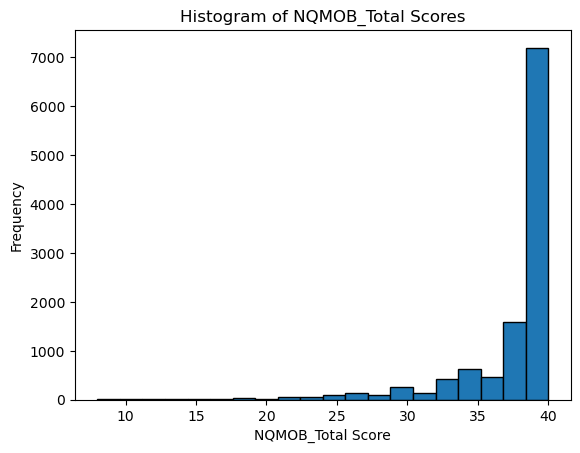

In [21]:
# Visualise the Neuro-QOL Lower Extremity DataFrame using the NQMOB_Total column
neuro_qol_lower_df['NQMOB_Total'].describe()

# Graph histogram of NQMOB_Total
import matplotlib.pyplot as plt
plt.hist(neuro_qol_lower_df['NQMOB_Total'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram of NQMOB_Total Scores')
plt.xlabel('NQMOB_Total Score')
plt.ylabel('Frequency')
plt.show()

### Neuro_QoL__Upper_Extremity_Function_-_Short_Form_14Dec2025.csv

In [22]:
neuro_qol_upper_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Neuro_QoL__Upper_Extremity_Function_-_Short_Form_14Dec2025.csv')
neuro_qol_upper_df.head(5)

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,NQUEX29,NQUEX20,NQUEX44,NQUEX36,NQUEX30,NQUEX28,NQUEX33,NQUEX37,ORIG_ENTRY,LAST_UPDATE
0,736294001,3000,V15,NQOLUEFS,03/2019,5,5.0,5.0,5.0,5,5,5,5.0,04/2019,2020-06-25 16:02:24
1,IA135021,3000,V17,NQOLUEFS,05/2021,5,5.0,5.0,5.0,5,5,5,5.0,06/2021,2021-06-01 00:00:00
2,733239701,3001,V15,NQOLUEFS,03/2019,4,5.0,5.0,5.0,4,4,5,5.0,03/2019,2020-06-25 16:04:36
3,IA135022,3001,V17,NQOLUEFS,09/2021,4,4.0,5.0,5.0,2,3,4,5.0,01/2022,2022-01-06 00:00:00
4,IA135023,3001,V18,NQOLUEFS,07/2022,4,4.0,4.0,4.0,2,3,4,5.0,07/2022,2022-07-08 00:00:00


In [23]:
def create_neuro_qol_upper_df(file_path):
    # 1. Load the raw Neuro-QOL Upper file
    neuro_qol_upper_df = pd.read_csv(file_path)

    # 2. Define the exact columns needed
    columns_to_keep = [
        'REC_ID',
        'PATNO',
        'EVENT_ID',
        'INFODT',
        'NQUEX29',
        'NQUEX20',
        'NQUEX44',
        'NQUEX36',
        'NQUEX30',
        'NQUEX28',
        'NQUEX33',
        'NQUEX37',
        'LAST_UPDATE'
    ]
    
    # 3. Create the subset DataFrame
    neuro_qol_upper_df = neuro_qol_upper_df[columns_to_keep].copy()

    # Filter using your Master Key
    neuro_qol_upper_df = neuro_qol_upper_df[neuro_qol_upper_df['PATNO'].isin(master_df['PATNO'])]

        # 4. Create another column for NQUEX_Total as the sum of the individual items
    neuro_qol_upper_df['NQUEX_Total'] = neuro_qol_upper_df[[
        'NQUEX29',
        'NQUEX20',
        'NQUEX44',
        'NQUEX36',
        'NQUEX30',
        'NQUEX28',
        'NQUEX33',
        'NQUEX37'
    ]].sum(axis=1)

        # 5. Add the cohort information from the master key
    neuro_qol_upper_df = pd.merge(
        neuro_qol_upper_df,
        master_df[['PATNO', 'COHORT_DEFINITION']],
        on='PATNO',
        how='left'
    )

    # ---------------------------------------------------------
    # CLEANUP
    # ---------------------------------------------------------
    # Reset index for a clean dataframe
    neuro_qol_upper_df.reset_index(drop=True, inplace=True)

    # Convert INFODT to datetime
    neuro_qol_upper_df['INFODT'] = pd.to_datetime(neuro_qol_upper_df['INFODT'],format='%m/%Y')
    
    # Merge with Master Key to get the Anchor Date (ENROLL_DATE)
    neuro_qol_upper_df = pd.merge(neuro_qol_upper_df, master_df[['PATNO', 'ENROLL_DATE']], on='PATNO', how='left')

    # 6. Calculate Timeline
    neuro_qol_upper_df['Months_Since_Enrollment'] = (
        (neuro_qol_upper_df['INFODT'] - neuro_qol_upper_df['ENROLL_DATE']) / pd.Timedelta(days=30.44)
    ).round().astype('Int64')
    # Rename for consistency
    neuro_qol_upper_df = neuro_qol_upper_df.rename(columns={'INFODT': 'VISIT_DATE'})

    return neuro_qol_upper_df

# --- EXECUTION ---
file_path = '../../ppmi_pd/Motor___MDS-UPDRS/Neuro_QoL__Upper_Extremity_Function_-_Short_Form_14Dec2025.csv'
neuro_qol_upper_df = create_neuro_qol_upper_df(file_path)

neuro_qol_upper_df.shape

(11237, 17)

**Higher NQUEX_Total means higher mobility.**

In [24]:
neuro_qol_upper_df['NQUEX_Total'].describe()

count    11237.000000
mean        38.778589
std          2.785674
min          8.000000
25%         39.000000
50%         40.000000
75%         40.000000
max         40.000000
Name: NQUEX_Total, dtype: float64

In [25]:
neuro_qol_upper_df[['PATNO','EVENT_ID','VISIT_DATE','NQUEX_Total','COHORT_DEFINITION']].head(10)

,PATNO,EVENT_ID,VISIT_DATE,NQUEX_Total,COHORT_DEFINITION
0,3000,V15,2019-03-01,40.0,Healthy Control
1,3000,V17,2021-05-01,40.0,Healthy Control
2,3001,V15,2019-03-01,37.0,Parkinson's Disease
3,3001,V17,2021-09-01,32.0,Parkinson's Disease
4,3001,V18,2022-07-01,30.0,Parkinson's Disease
5,3001,V19,2023-03-01,32.0,Parkinson's Disease
6,3001,V20,2024-09-01,28.0,Parkinson's Disease
7,3002,V15,2019-03-01,34.0,Parkinson's Disease
8,3002,V17,2021-09-01,30.0,Parkinson's Disease
9,3002,V18,2022-03-01,26.0,Parkinson's Disease


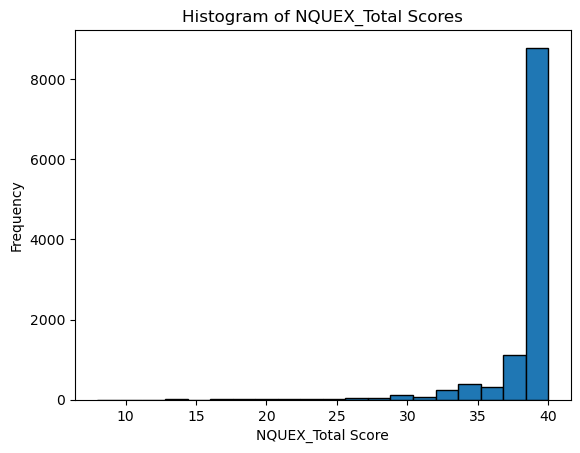

In [26]:
# Visualise the Neuro-QOL Upper Extremity DataFrame using the NQUEX_Total column
neuro_qol_upper_df['NQUEX_Total'].describe()

# Graph histogram of NQUEX_Total
import matplotlib.pyplot as plt
plt.hist(neuro_qol_upper_df['NQUEX_Total'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram of NQUEX_Total Scores')
plt.xlabel('NQUEX_Total Score')
plt.ylabel('Frequency')
plt.show()

In [27]:
# Find the patient with the lowest NQUEX_Total score
neuro_qol_upper_df[neuro_qol_upper_df['NQUEX_Total']==8]

,REC_ID,PATNO,EVENT_ID,VISIT_DATE,NQUEX29,NQUEX20,NQUEX44,NQUEX36,NQUEX30,NQUEX28,NQUEX33,NQUEX37,LAST_UPDATE,NQUEX_Total,COHORT_DEFINITION,ENROLL_DATE,Months_Since_Enrollment
4577,IA137256,101557,BL,2021-06-01,1,1.0,1.0,1.0,1,1,1,1.0,2021-07-01 00:00:00,8.0,Parkinson's Disease,2021-07-01,-1


In [28]:
# Check the patient NQUEX_Total score overtime
neuro_qol_upper_df[neuro_qol_upper_df['PATNO']==101557]

,REC_ID,PATNO,EVENT_ID,VISIT_DATE,NQUEX29,NQUEX20,NQUEX44,NQUEX36,NQUEX30,NQUEX28,NQUEX33,NQUEX37,LAST_UPDATE,NQUEX_Total,COHORT_DEFINITION,ENROLL_DATE,Months_Since_Enrollment
4577,IA137256,101557,BL,2021-06-01,1,1.0,1.0,1.0,1,1,1,1.0,2021-07-01 00:00:00,8.0,Parkinson's Disease,2021-07-01,-1
4578,IA137257,101557,V04,2022-07-01,5,4.0,5.0,5.0,5,5,5,4.0,2022-07-14 00:00:00,38.0,Parkinson's Disease,2021-07-01,12
4579,IA288799,101557,V06,2023-06-01,5,5.0,5.0,5.0,5,5,5,5.0,2023-06-27 00:00:00,40.0,Parkinson's Disease,2021-07-01,23
4580,IA523363,101557,V08,2024-07-01,5,5.0,5.0,5.0,4,5,5,5.0,2024-07-02 00:00:00,39.0,Parkinson's Disease,2021-07-01,36
4581,IA774656,101557,V10,2025-07-01,5,3.0,5.0,5.0,4,5,5,5.0,2025-07-01 00:00:00,37.0,Parkinson's Disease,2021-07-01,48


### Participant_Motor_Function_Questionnaire_14Dec2025.csv
* possible to skip since not much influence on the study

In [29]:
participant_motor_function_df = pd.read_csv('../../ppmi_pd/Motor___MDS-UPDRS/Participant_Motor_Function_Questionnaire_14Dec2025.csv')
participant_motor_function_df.head(5)

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,CMPLBY2,TRBUPCHR,WRTSMLR,VOICSFTR,POORBAL,FTSTUCK,LSSXPRSS,ARMLGSHK,TRBBUTTN,SHUFFLE,MVSLOW,TOLDPD,ORIG_ENTRY,LAST_UPDATE
0,IA71336,3000,V17,PQUEST,05/2021,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,06/2021,2021-06-01 00:00:00
1,IA71337,3001,V17,PQUEST,09/2021,1,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,01/2022,2022-01-06 00:00:00
2,IA71338,3001,V18,PQUEST,07/2022,1,1.0,1.0,1.0,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,07/2022,2022-07-08 00:00:00
3,IA249051,3001,V19,PQUEST,03/2023,1,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,03/2023,2023-03-29 00:00:00
4,IA583072,3001,V20,PQUEST,09/2024,1,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,09/2024,2024-09-25 00:00:00


In [30]:
participant_motor_function_df.shape

(10962, 19)

In [31]:
def create_participant_motor_function_df(file_path, master_df):
    # 1. Load the raw Participant Motor Function file
    pmfq_df = pd.read_csv(file_path)

    # 2. Define the exact columns needed
    # Separation helps us know what to SUM vs what is METADATA
    symptom_cols = [
        'TRBUPCHR', # Trouble getting up from chair
        'WRTSMLR',  # Handwriting smaller
        'VOICSFTR', # Voice softer
        'POORBAL',  # Poor balance
        'FTSTUCK',  # Feet stuck to floor
        'LSSXPRSS', # Face less expressive
        'ARMLGSHK', # Arms/Legs shaking
        'TRBBUTTN', # Trouble buttoning buttons
        'SHUFFLE',  # Shuffling feet
        'MVSLOW'    # Moving slower
    ]
    
    meta_cols = [
        'REC_ID', 'PATNO', 'EVENT_ID', 'INFODT', 
        'CMPLBY2', # Completed by (1=Patient, 2=Both, 3=Caregiver)
        'TOLDPD'   # Told you have PD? (Yes/No) - Do not sum this!
    ]
    
    # 3. Create the subset DataFrame
    pmfq_df = pmfq_df[meta_cols + symptom_cols].copy()

    # 4. Filter using your Master Key
    pmfq_df = pmfq_df[pmfq_df['PATNO'].isin(master_df['PATNO'])]

    # ---------------------------------------------------------
    # SCORING LOGIC (The Fix)
    # ---------------------------------------------------------
    # Problem: Values are 0=No, 1=Yes, 2=Uncertain
    # If we sum blindly, "Uncertain" (2) counts double "Yes" (1). That is wrong.
    # Fix: Replace 2 with 0.5 (weighted as "Maybe") OR 0 (Conservative). 
    # We will use 0.5 to capture the signal without exaggeration.
    for col in symptom_cols:
        # Ensure numeric first (coerces errors to NaN)
        pmfq_df[col] = pd.to_numeric(pmfq_df[col], errors='coerce')
        pmfq_df[col] = pmfq_df[col].replace({2: 0.5})

    # 6. Create the Total Score
    # We sum ONLY the symptom columns, not the metadata
    pmfq_df['Self_Reported_Symptom_Count'] = pmfq_df[symptom_cols].sum(axis=1)

    # 7. Add Cohort Information
    pmfq_df = pd.merge(
        pmfq_df,
        master_df[['PATNO', 'COHORT_DEFINITION', 'ENROLL_DATE']],
        on='PATNO',
        how='left'
    )

    # ---------------------------------------------------------
    # CLEANUP & DATES
    # ---------------------------------------------------------
    # Convert INFODT to datetime
    pmfq_df['INFODT'] = pd.to_datetime(pmfq_df['INFODT'], errors='coerce', format='%m/%Y')

    # Calculate Timeline
    pmfq_df['Months_Since_Enrollment'] = (
        (pmfq_df['INFODT'] - pmfq_df['ENROLL_DATE']) / pd.Timedelta(days=30.44)
    ).round().astype('Int64')

    # Rename for consistency
    pmfq_df = pmfq_df.rename(columns={'INFODT': 'VISIT_DATE'})
    
    # Reset index
    pmfq_df.reset_index(drop=True, inplace=True)

    return pmfq_df

# --- EXECUTION ---
# Make sure the path points to the MOTOR FUNCTION file, not Neuro-QoL
file_path = '../../ppmi_pd/Motor___MDS-UPDRS/Participant_Motor_Function_Questionnaire_14Dec2025.csv'

# Ensure master_df exists from previous steps
# master_df = create_master_key(...) 

participant_motor_func_df = create_participant_motor_function_df(file_path, master_df)

# Check results
print(f"Shape: {participant_motor_func_df.shape}")
print(participant_motor_func_df[['PATNO', 'VISIT_DATE', 'Self_Reported_Symptom_Count']].head())
participant_motor_func_df.head(10)

Shape: (10841, 20)
   PATNO VISIT_DATE  Self_Reported_Symptom_Count
0   3000 2021-05-01                          0.0
1   3001 2021-09-01                          8.0
2   3001 2022-07-01                          8.5
3   3001 2023-03-01                          8.0
4   3001 2024-09-01                          9.0


,REC_ID,PATNO,EVENT_ID,VISIT_DATE,CMPLBY2,TOLDPD,TRBUPCHR,WRTSMLR,VOICSFTR,POORBAL,FTSTUCK,LSSXPRSS,ARMLGSHK,TRBBUTTN,SHUFFLE,MVSLOW,Self_Reported_Symptom_Count,COHORT_DEFINITION,ENROLL_DATE,Months_Since_Enrollment
0,IA71336,3000,V17,2021-05-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Healthy Control,2011-02-01,123
1,IA71337,3001,V17,2021-09-01,1,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,8.0,Parkinson's Disease,2011-03-01,126
2,IA71338,3001,V18,2022-07-01,1,1.0,1.0,1.0,1.0,0.5,1.0,0.0,1.0,1.0,1.0,1.0,8.5,Parkinson's Disease,2011-03-01,136
3,IA249051,3001,V19,2023-03-01,1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,8.0,Parkinson's Disease,2011-03-01,144
4,IA583072,3001,V20,2024-09-01,1,1.0,1.0,1.0,1.0,1.0,0.5,0.5,1.0,1.0,1.0,1.0,9.0,Parkinson's Disease,2011-03-01,162
5,IA71339,3002,V17,2021-09-01,1,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,8.0,Parkinson's Disease,2011-03-01,126
6,IA71340,3002,V18,2022-03-01,1,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,9.0,Parkinson's Disease,2011-03-01,132
7,IA71341,3003,V18,2022-04-01,1,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,7.0,Parkinson's Disease,2011-04-01,132
8,IA264831,3003,V19,2023-05-01,1,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,4.0,Parkinson's Disease,2011-04-01,145
9,IA485702,3003,V20,2024-05-01,1,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,5.0,Parkinson's Disease,2011-04-01,157


**Self_Reported_Symptom_Count**

* 0 = No symptoms reported (Perfectly healthy).

* 10 = All symptoms reported (Severe issues).

In [32]:
# describe the Self_Reported_Symptom_Count column
participant_motor_func_df['Self_Reported_Symptom_Count'].describe()

count    10841.000000
mean         2.248086
std          2.652542
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         10.000000
Name: Self_Reported_Symptom_Count, dtype: float64

## Non-Motor Assessments

### Montreal_Cognitive_Assessment__MoCA__14Dec2025.csv

In [66]:
def create_moca_df(moca_file_path, edu_file_path, master_df):
    """
    Preprocesses the Montreal Cognitive Assessment (MoCA).
    - Filters valid visits.
    - Applies Education Adjustment (+1 if Years of Education <= 12).
    - Creates Clinical Status categories (Normal vs MCI vs Dementia).
    """
    # 1. Load Data
    moca = pd.read_csv(moca_file_path)
    edu = pd.read_csv(edu_file_path)

    # 2. Filter by Master Key & Events
    moca = moca[moca['PATNO'].isin(master_df['PATNO'])]
    
    # Remove Screening(SC) and Unscheduled(U01)
    # Note: We keep SC for MoCA sometimes as a baseline, but usually BL is preferred.
    # Let's stick to the standard exclusion for consistency.
    events_to_remove = ['SC', 'ST', 'U01']
    moca = moca[~moca['EVENT_ID'].isin(events_to_remove)]

    # 3. Handle Education Adjustment
    # We need to merge the static 'EDUCYRS' from Socio-Economics file
    edu_subset = edu[['PATNO', 'EDUCYRS']].copy()
    
    # Merge Education into MoCA
    df = pd.merge(moca, edu_subset, on='PATNO', how='left')

    # Ensure numeric
    df['MCATOT'] = pd.to_numeric(df['MCATOT'], errors='coerce')
    df['EDUCYRS'] = pd.to_numeric(df['EDUCYRS'], errors='coerce')

    def calculate_adjusted_moca(row):
        score = row['MCATOT']
        years_edu = row['EDUCYRS']
        
        # If score is missing, return NaN
        if pd.isna(score):
            return np.nan
            
        # Education Adjustment Rule:
        # If Education <= 12 years AND Score < 30, add 1 point.
        if (not pd.isna(years_edu)) and (years_edu <= 12) and (score < 30):
            score += 1
            
        return score

    df['MoCA_Total_Adjusted'] = df.apply(calculate_adjusted_moca, axis=1)

    # 4. Create Cognitive Categories (Feature Engineering)
    # These cutoff scores are standard in PD research
    def categorize_cognition(score):
        if pd.isna(score):
            return 'Unknown'
        elif score >= 26:
            return 'Normal'
        elif score >= 21:
            return 'MCI' # Mild Cognitive Impairment
        else:
            return 'Dementia' # <= 20

    df['Cognitive_Status'] = df['MoCA_Total_Adjusted'].apply(categorize_cognition)
    
    # Encode as ordinal for ML (0=Normal, 1=MCI, 2=Dementia)
    # Higher is WORSE (Disease Progression)
    status_map = {'Normal': 0, 'MCI': 1, 'Dementia': 2, 'Unknown': np.nan}
    df['Cognitive_Status_Code'] = df['Cognitive_Status'].map(status_map)

    # 5. Final Cleanup
    cols_to_keep = [
        'PATNO', 'EVENT_ID', 'INFODT', 
        'MoCA_Total_Adjusted', 
        'Cognitive_Status_Code',
        'EDUCYRS' # Keep this as a feature too
    ]
    
    df = df[cols_to_keep].copy()
    
    # Rename for consistency
    df = df.rename(columns={'INFODT': 'VISIT_DATE', 'MoCA_Total_Adjusted': 'MoCA_Score'})
    df['VISIT_DATE'] = pd.to_datetime(df['VISIT_DATE'], errors='coerce')
    df.reset_index(drop=True, inplace=True)

    return df

# --- EXECUTION ---
# moca_path = 'Non-motor_Assessments/Montreal_Cognitive_Assessment__MoCA__14Dec2025.csv'
# edu_path = 'Subject_Demographics/Socio-Economics_14Dec2025.csv'
# moca_df = create_moca_df(moca_path, edu_path, master_df)